# Aircraft Type Classification - Context Aware Systems Project

**Course:** Context Aware Systems - Master in Computer Engineering (Mobile Computing)
**Institution:** Escola Superior de Tecnologia e Gestão, Politécnico de Leiria
**Academic Year:** 2025/2026

---

## Abstract

This notebook presents the complete pipeline for training and evaluating deep learning models for fine-grained aircraft type classification. Starting from raw collection of over 80,000 images across 130 aircraft classes, we built a clean, stratified dataset of **115 aircraft classes** and approximately **63,500 images** through a multi-stage preprocessing pipeline.

To fulfill the project requirements, we trained and compared two distinct model families:
- **Model S** - a custom Convolutional Neural Network designed from scratch, incorporating channel attention (Squeeze-and-Excitation blocks), Batch Normalisation, GELU activations, and Dropout regularisation.
- **Model T** - transfer learning using a pretrained **EfficientNetV2-M** backbone, evaluated under both feature-extraction and full fine-tuning strategies.

For each model family, we systematically vary augmentation, loss function (Weighted Cross-Entropy vs. Label Smoothing Cross-Entropy), and optimiser (Adam vs. SGD with Momentum) to identify the combination that yields the best generalisation on the held-out test set.

All experiments are evaluated using accuracy, precision, recall, F1 score, and confusion matrices.

---

## Framework Choice: PyTorch vs. TensorFlow/Keras

For this project, we explicitly chose **PyTorch** over TensorFlow/Keras as our deep learning framework. 

While Keras allows for rapid prototyping via high-level wrappers (e.g., `model.fit()`), it hides the underlying mathematical processes. For a Master's level project, we required **maximum visibility and granular control over every training step**. 

1. Because this project requires a detailed report explaining every modelling decision, PyTorch's explicit training loop is a significant advantage: there is nothing hidden, and every line of code directly corresponds to a step described in the report.
2. Systematically swapping between multiple loss functions and optimizers requires precise, line-by-line manipulation of the training loop.
3. Managing a massive dataset on local hardware (RTX 3050 Ti with 4GB VRAM) requires strict memory management. PyTorch's dynamic computation graph, combined with mixed-precision training (`torch.autocast`), gave us the exact control needed to maximize batch sizes and training speed without triggering Out-Of-Memory (OOM) errors.



---

## 0. Dataset Preparation

### 0.1 Data Sources

The dataset was assembled from **13 publicly available sources**, collected via [Google Dataset Search](https://datasetsearch.research.google.com/) and [Kaggle](https://www.kaggle.com/).

The sources varied significantly in format, annotation style, and quality, requiring a custom preprocessing pipeline before any model training could begin.

| Source                               | Format | Notes |
|--------------------------------------|--------|-------|
| FGVC-Aircraft 2013b                  | CSV (train/val/test) | 100 aircraft variants, bounding boxes available |
| Kaggle - Military Aircraft Detection | YOLO `.txt` (normalised bbox) | Multi-aircraft images, required cropping |
| Kaggle - Aircraft Dataset            | Pre-sorted folders | Already split train/test/val |
| *(+ 10 further datasets)*            | Mixed | Folder-sorted or annotated |


**Why multiple sources?**

No single public dataset includes all 124 aircraft classes with enough images. Because of this, we combined multiple datasets to increase the number of classes covered and to include more variation in the images

**Why we used more than the minimum number of images?**

Even though the project requirement was at least 2000 training images, this is quite small for a classification problem. To improve performance, we increased the dataset size to over 80,000 images before preprocessing. Having more data helps the model generalize better and reduces the risk of overfitting. It also allows for better class balance and makes data augmentation more effective.

**Challenges**

Using multiple datasets also created some challenges, such as differences in image quality, formats, and possible label inconsistencies. To handle this, we applied preprocessing steps like resizing, normalization, and cleaning to make the data more consistent.

**Important Note**

The dataset preparation step was performed locally, outside the Jupyter Notebook, using standard Python scripts.

---

### 0.2 Preprocessing Pipeline

Because each source used a different annotation convention, a multi-stage preprocessing pipeline was developed:

```
[13 raw datasets]
      │
      ├─ CSV-annotated  -> script1.py    -> folder-sorted images
      ├─ YOLO-annotated -> script2.py    -> cropped + folder-sorted images
      └─ Pre-sorted     -> script3.py    -> merged into single flat structure
                                    │
                            [combined-aircrafts/]
                                    │
                            build_dataset.py
                            ├─ Phase 1: Inventory (recursive scan)
                            ├─ Phase 2: Deduplication (MD5 + pHash <= 2)
                            ├─ Phase 3: Taxonomy mapping (124 variants)
                            └─ Phase 4: Stratified split -> train / valid / test
                                    │
                            [clean-dataset/]
```

**Key decisions made during preprocessing:**

- **YOLO-format datasets** contained images with multiple aircraft. Each bounding box annotation was used to crop individual aircraft instances, producing one image per aircraft rather than one image per scene.
- **CSV-format datasets** (e.g. FGVC-Aircraft) were sorted into class folders using the provided split files, preserving the original train/val/test assignments before re-splitting.
- **Pre-sorted datasets** were flattened into a single combined folder to allow the pipeline to re-split them in a consistent, stratified manner.
- **Deduplication** was performed in two passes: exact duplicates via MD5 hash, and near-duplicates via perceptual hash (pHash) with a Hamming distance threshold of <= 2. This threshold catches JPEG re-saves and minor colour-shifted copies while preserving genuinely distinct images.
- **Minimum class size** of 50 images was enforced. Classes below this threshold were excluded from the final dataset.
- **Stratified splitting** (70% train / 15% valid / 15% test) was applied per variant to ensure each class is proportionally represented across all three splits.

### 0.3 Source Preprocessing Scripts

The four scripts below are included for full reproducibility. They were run **outside this notebook** as standalone Python scripts prior to any model training. They are presented here so that every data engineering decision is auditable alongside the modelling work.

Each script addresses one annotation format found across the 13 source datasets:
- **Script 1** handles CSV-annotated sources (e.g. FGVC-Aircraft 2013b)
- **Script 2** handles YOLO-format annotations by cropping individual aircraft from multi-aircraft scenes
- **Script 3** merges pre-split datasets back into a flat per-class structure for consistent re-splitting
- **Script 4** (`build_dataset.py`) is the main pipeline: deduplication -> taxonomy -> stratified split -> export

In [ ]:
# Script 1: CSV-annotated datasets
# Reads train.csv / val.csv / test.csv and copies images into output/<split>/<class_name>/ folders.
# Used for: FGVC-Aircraft 2013b

import csv
import shutil
from pathlib import Path

IMAGE_SOURCE_DIR = r"path/to/images"
CSV_DIR          = r"path/to/csv/files"
OUTPUT_DIR       = r"path/to/output/dir"

def process_csv(csv_path, split_name, image_source, output_root):
    if not csv_path.exists():
        print(f"[Warning] {csv_path.name} not found - skipping.")
        return
    copied = missing = 0
    with open(csv_path, encoding="utf-8") as f:
        for row in csv.DictReader(f):
            keys      = list(row.keys())
            file_key  = next((k for k in keys if "filename" in k.lower()), None)
            class_key = next((k for k in keys if "class"    in k.lower()), None)
            if not file_key or not class_key:
                print("  [Error] Cannot identify filename/class columns."); return
            src  = Path(image_source) / row[file_key].strip()
            dest = Path(output_root) / split_name / row[class_key].strip() / src.name
            if src.exists():
                dest.parent.mkdir(parents=True, exist_ok=True)
                if not dest.exists():
                    shutil.copy2(src, dest)
                copied += 1
            else:
                missing += 1
    print(f"  [{split_name}] Copied: {copied}  Missing: {missing}")

for split in ["train", "test", "val"]:
    process_csv(Path(CSV_DIR) / f"{split}.csv", split,
                IMAGE_SOURCE_DIR, OUTPUT_DIR)
print("CSV sort complete.")

In [ ]:
# Script 2: YOLO-annotated datasets
# Reads normalized YOLO .txt annotations, crops individual aircraft from each scene image, and saves one image per detection.
# Used for: Military Aircraft Detection dataset (Kaggle)

from pathlib import Path
from PIL import Image

DATASET_DIR = r"path/to/unpacked/dataset"
OUTPUT_DIR  = r"path/where/to/save/ouput"
IMG_EXTS    = {".jpg", ".jpeg", ".png"}

def find_image(images_dir, stem):
    for ext in IMG_EXTS:
        p = images_dir / (stem + ext)
        if p.exists(): return p
    return None

def yolo_to_crop(line, W, H):
    cls, cx, cy, bw, bh = line.split()
    cx, cy, bw, bh = float(cx)*W, float(cy)*H, float(bw)*W, float(bh)*H
    return cls, (max(0,int(cx-bw/2)), max(0,int(cy-bh/2)),
                 min(W,int(cx+bw/2)), min(H,int(cy+bh/2)))

for split in ["train", "test"]:
    labels_dir = Path(DATASET_DIR) / split / "labels"
    images_dir = Path(DATASET_DIR) / split / "images"
    if not labels_dir.exists(): continue
    print(f"Processing {split}…")
    for txt in labels_dir.glob("*.txt"):
        img_path = find_image(images_dir, txt.stem)
        if not img_path: continue
        try:
            with Image.open(img_path) as img:
                W, H = img.size
                for i, line in enumerate(txt.read_text().splitlines()):
                    if not line.strip(): continue
                    cls, box = yolo_to_crop(line, W, H)
                    out_dir = Path(OUTPUT_DIR) / split / cls
                    out_dir.mkdir(parents=True, exist_ok=True)
                    img.crop(box).save(out_dir / f"{txt.stem}_crop{i}{img_path.suffix}")
        except Exception as e:
            print(f"  [Error] {img_path.name}: {e}")
print("YOLO crop complete.")

In [ ]:
# Script 3: Merge pre-sorted datasets into one flat structure
import shutil
from pathlib import Path

BASE_DIR   = Path(r"E:\final-dataset\non-sorted\csv_sorted_aircrafts")
OUTPUT_DIR = BASE_DIR.parent / "combined_aircrafts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for split in ["test", "train", "val"]:
    split_dir = BASE_DIR / split
    if not split_dir.exists(): continue
    for file_path in split_dir.rglob("*"):
        if not file_path.is_file(): continue
        dest = OUTPUT_DIR / file_path.relative_to(split_dir)
        dest.parent.mkdir(parents=True, exist_ok=True)
        if dest.exists():                          # collision -> rename safely
            c = 1
            while dest.exists():
                dest = dest.with_name(f"{file_path.stem}_{split}_{c}{file_path.suffix}")
                c += 1
        shutil.copy2(file_path, dest)
print("Directories combined.")

In [ ]:
# Dataset Building Pipeline
# This script scans raw images, removes duplicates (MD5 and pHash),
# applies the taxonomy, splits the data, and writes the final dataset to disk.

import hashlib
import logging
import sys
import uuid
import shutil
from pathlib import Path

import imagehash
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

# Configuration
SOURCE_ROOT = r"D:\path\to\raw\images"       # <-- Edit this
OUTPUT_ROOT = r"D:\path\to\clean-dataset"    # <-- Edit this

MIN_IMAGES_PER_CLASS = 50
PHASH_THRESHOLD = 2
SPLIT_RATIOS = (0.70, 0.15, 0.15)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff", ".tif"}

# Taxonomy
TAXONOMY: dict[str, tuple[str, str, str]] = {
    # Boeing narrow-body
    "707-320": ("Boeing", "707", "Boeing 707-320"),
    "boeing 707": ("Boeing", "707", "Boeing 707"),
    "727-200": ("Boeing", "727", "Boeing 727-200"),
    "boeing 727": ("Boeing", "727", "Boeing 727"),
    "737-200": ("Boeing", "737", "Boeing 737-200"),
    "737-300": ("Boeing", "737", "Boeing 737-300"),
    "737-400": ("Boeing", "737", "Boeing 737-400"),
    "737-500": ("Boeing", "737", "Boeing 737-500"),
    "737-600": ("Boeing", "737", "Boeing 737-600"),
    "737-700": ("Boeing", "737", "Boeing 737-700"),
    "737-800": ("Boeing", "737", "Boeing 737-800"),
    "737-900": ("Boeing", "737", "Boeing 737-900"),
    "boeing 737": ("Boeing", "737", "Boeing 737"),
    "757-200": ("Boeing", "757", "Boeing 757-200"),
    "757-300": ("Boeing", "757", "Boeing 757-300"),
    "boeing 757": ("Boeing", "757", "Boeing 757"),
    "717": ("Boeing", "717", "Boeing 717"),
    "boeing 717": ("Boeing", "717", "Boeing 717"),
    # Boeing wide-body
    "747-100": ("Boeing", "747", "Boeing 747-100"),
    "747-200": ("Boeing", "747", "Boeing 747-200"),
    "747-300": ("Boeing", "747", "Boeing 747-300"),
    "747-400": ("Boeing", "747", "Boeing 747-400"),
    "boeing 747": ("Boeing", "747", "Boeing 747"),
    "767-200": ("Boeing", "767", "Boeing 767-200"),
    "767-300": ("Boeing", "767", "Boeing 767-300"),
    "767-400": ("Boeing", "767", "Boeing 767-400"),
    "boeing 767": ("Boeing", "767", "Boeing 767"),
    "777-200": ("Boeing", "777", "Boeing 777-200"),
    "777-300": ("Boeing", "777", "Boeing 777-300"),
    "boeing 777": ("Boeing", "777", "Boeing 777"),
    # Boeing legacy
    "dc-3": ("Douglas", "DC-3", "DC-3"),
    "dc-6": ("Douglas", "DC-6", "DC-6"),
    "dc-8": ("Douglas", "DC-8", "DC-8"),
    "dc-9-30": ("Douglas", "DC-9", "DC-9-30"),
    "dc-10": ("McDonnell Douglas", "DC-10", "DC-10"),
    "md-11": ("McDonnell Douglas", "MD-11", "MD-11"),
    "md-80": ("McDonnell Douglas", "MD-80", "MD-80"),
    "md-87": ("McDonnell Douglas", "MD-87", "MD-87"),
    "md-90": ("McDonnell Douglas", "MD-90", "MD-90"),
    "l-1011": ("Lockheed", "L-1011", "L-1011"),
    # Airbus narrow-body
    "a318": ("Airbus", "A320 family", "Airbus A318"),
    "airbus a318": ("Airbus", "A320 family", "Airbus A318"),
    "a319": ("Airbus", "A320 family", "Airbus A319"),
    "airbus a319": ("Airbus", "A320 family", "Airbus A319"),
    "a320": ("Airbus", "A320 family", "Airbus A320"),
    "airbus a320": ("Airbus", "A320 family", "Airbus A320"),
    "a321": ("Airbus", "A320 family", "Airbus A321"),
    "airbus a321": ("Airbus", "A320 family", "Airbus A321"),
    # Airbus wide-body
    "a300b4": ("Airbus", "A300", "Airbus A300B4"),
    "a300": ("Airbus", "A300", "Airbus A300"),
    "airbus a300": ("Airbus", "A300", "Airbus A300"),
    "a310": ("Airbus", "A310", "Airbus A310"),
    "airbus a310": ("Airbus", "A310", "Airbus A310"),
    "a330-200": ("Airbus", "A330", "Airbus A330-200"),
    "a330-300": ("Airbus", "A330", "Airbus A330-300"),
    "a330": ("Airbus", "A330", "Airbus A330"),
    "airbus a330": ("Airbus", "A330", "Airbus A330"),
    "a340-200": ("Airbus", "A340", "Airbus A340-200"),
    "a340-300": ("Airbus", "A340", "Airbus A340-300"),
    "a340-500": ("Airbus", "A340", "Airbus A340-500"),
    "a340-600": ("Airbus", "A340", "Airbus A340-600"),
    "a340": ("Airbus", "A340", "Airbus A340"),
    "airbus a340": ("Airbus", "A340", "Airbus A340"),
    "a380": ("Airbus", "A380", "Airbus A380"),
    "airbus a380": ("Airbus", "A380", "Airbus A380"),
    "a220": ("Airbus", "A220", "Airbus A220"),
    "airbus a220": ("Airbus", "A220", "Airbus A220"),
    "a350": ("Airbus", "A350", "Airbus A350"),
    "airbus a350": ("Airbus", "A350", "Airbus A350"),
    # Regional jets
    "crj-200": ("Bombardier", "CRJ", "CRJ-200"),
    "crj-700": ("Bombardier", "CRJ", "CRJ-700"),
    "crj-900": ("Bombardier", "CRJ", "CRJ-900"),
    "challenger 600": ("Bombardier", "Challenger", "Challenger 600"),
    "global express": ("Bombardier", "Global", "Global Express"),
    "e-170": ("Embraer", "E-Jet", "Embraer E-170"),
    "e-190": ("Embraer", "E-Jet", "Embraer E-190"),
    "e-195": ("Embraer", "E-Jet", "Embraer E-195"),
    "embraer e-jet": ("Embraer", "E-Jet", "Embraer E-Jet"),
    "e170": ("Embraer", "E-Jet", "Embraer E-170"),
    "e190": ("Embraer", "E-Jet", "Embraer E-190"),
    "erj 135": ("Embraer", "ERJ", "ERJ 135"),
    "erj 145": ("Embraer", "ERJ", "ERJ 145"),
    "embraer erj 145": ("Embraer", "ERJ", "ERJ 145"),
    "emb-120": ("Embraer", "EMB-120", "EMB-120"),
    "embraer legacy 600": ("Embraer", "Legacy", "Embraer Legacy 600"),
    "fokker 100": ("Fokker", "Fokker", "Fokker 100"),
    "fokker 50": ("Fokker", "Fokker", "Fokker 50"),
    "fokker 70": ("Fokker", "Fokker", "Fokker 70"),
    # Turboprop regional
    "atr-42": ("ATR", "ATR", "ATR-42"),
    "atr-72": ("ATR", "ATR", "ATR-72"),
    "atr": ("ATR", "ATR", "ATR"),
    "dash 8": ("De Havilland Canada", "Dash 8", "Dash 8"),
    "dhc-8-100": ("De Havilland Canada", "Dash 8", "Dash 8-100"),
    "dhc-8-300": ("De Havilland Canada", "Dash 8", "Dash 8-300"),
    "dhc-6": ("De Havilland Canada", "DHC-6", "DHC-6"),
    "dhc-1": ("De Havilland Canada", "DHC-1", "DHC-1"),
    "dh-82": ("De Havilland", "Tiger Moth", "DH-82 Tiger Moth"),
    "saab 2000": ("Saab", "Saab", "Saab 2000"),
    "saab 340": ("Saab", "Saab", "Saab 340"),
    "dornier 328": ("Dornier", "328", "Dornier 328"),
    "beechcraft 1900": ("Beechcraft", "1900", "Beechcraft 1900"),
    "bae 146-200": ("BAE Systems", "BAE 146", "BAE 146-200"),
    "bae 146-300": ("BAE Systems", "BAE 146", "BAE 146-300"),
    "bae 146": ("BAE Systems", "BAE 146", "BAE 146"),
    "bae-125": ("BAE Systems", "BAE-125", "BAE-125"),
    "metroliner": ("Fairchild", "Metroliner", "Metroliner"),
    "an-12": ("Antonov", "An-12", "An-12"),
    "an-22": ("Antonov", "An-22", "An-22"),
    "an22": ("Antonov", "An-22", "An-22"),
    "an-72": ("Antonov", "An-72", "An-72"),
    "an72": ("Antonov", "An-72", "An-72"),
    "an-124": ("Antonov", "An-124", "An-124"),
    "an124": ("Antonov", "An-124", "An-124"),
    "an-225": ("Antonov", "An-225", "An-225"),
    "an225": ("Antonov", "An-225", "An-225"),
    "il-76": ("Ilyushin", "Il-76", "Il-76"),
    "tu-134": ("Tupolev", "Tu-134", "Tu-134"),
    "tu-154": ("Tupolev", "Tu-154", "Tu-154"),
    "tu-160": ("Tupolev", "Tu-160", "Tu-160"),
    "tu160": ("Tupolev", "Tu-160", "Tu-160"),
    "tu-22m": ("Tupolev", "Tu-22M", "Tu-22M"),
    "tu22m": ("Tupolev", "Tu-22M", "Tu-22M"),
    "tu-95": ("Tupolev", "Tu-95", "Tu-95"),
    "tu95": ("Tupolev", "Tu-95", "Tu-95"),
    "yak-42": ("Yakovlev", "Yak-42", "Yak-42"),
    # General aviation
    "cessna 172": ("Cessna", "172", "Cessna 172"),
    "cessna 208": ("Cessna", "208", "Cessna 208 Caravan"),
    "cessna 525": ("Cessna", "Citation", "Cessna Citation CJ"),
    "cessna 560": ("Cessna", "Citation", "Cessna Citation V"),
    "cessna citation": ("Cessna", "Citation", "Cessna Citation"),
    "sr-20": ("Cirrus", "SR", "Cirrus SR-20"),
    "sr-22": ("Cirrus", "SR", "Cirrus SR-22"),
    "pa-28": ("Piper", "Cherokee", "Piper PA-28"),
    "dr-400": ("Robin", "DR-400", "Robin DR-400"),
    "model b200": ("Beechcraft", "King Air", "King Air B200"),
    "king air": ("Beechcraft", "King Air", "King Air"),
    # Business jets
    "falcon 2000": ("Dassault", "Falcon", "Falcon 2000"),
    "falcon 900": ("Dassault", "Falcon", "Falcon 900"),
    "gulfstream iv": ("Gulfstream", "Gulfstream", "Gulfstream IV"),
    "gulfstream v": ("Gulfstream", "Gulfstream", "Gulfstream V"),
    "gulfstream": ("Gulfstream", "Gulfstream", "Gulfstream"),
    # Military fixed-wing
    "c-130": ("Lockheed", "Hercules", "C-130 Hercules"),
    "c-17": ("Boeing", "Globemaster", "C-17 Globemaster III"),
    "c-47": ("Douglas", "C-47", "C-47 Skytrain"),
    "c-15": ("Boeing", "C-135", "C-135"),
    "b-1": ("Rockwell", "B-1", "B-1 Lancer"),
    "b-52": ("Boeing", "B-52", "B-52 Stratofortress"),
    "b2": ("Northrop Grumman", "B-2", "B-2 Spirit"),
    "a-10": ("Fairchild Republic", "A-10", "A-10 Thunderbolt II"),
    "f-4": ("McDonnell Douglas", "F-4", "F-4 Phantom II"),
    "f-14": ("Grumman", "F-14", "F-14 Tomcat"),
    "f-15": ("McDonnell Douglas", "F-15", "F-15 Eagle"),
    "f-16": ("General Dynamics", "F-16", "F-16 Fighting Falcon"),
    "f-16a": ("General Dynamics", "F-16", "F-16A"),
    "f-a-18": ("McDonnell Douglas", "F/A-18", "F/A-18 Hornet"),
    "f-a18": ("McDonnell Douglas", "F/A-18", "F/A-18 Hornet"),
    "f18": ("McDonnell Douglas", "F/A-18", "F/A-18 Hornet"),
    "f-22": ("Lockheed Martin", "F-22", "F-22 Raptor"),
    "f-35": ("Lockheed Martin", "F-35", "F-35 Lightning II"),
    "f-117": ("Lockheed", "F-117", "F-117 Nighthawk"),
    "ef-2000": ("Eurofighter", "Typhoon", "Eurofighter Typhoon"),
    "eurofighter typhoon": ("Eurofighter", "Typhoon", "Eurofighter Typhoon"),
    "jas-39": ("Saab", "Gripen", "JAS-39 Gripen"),
    "mig-31": ("Mikoyan", "MiG-31", "MiG-31"),
    "mig31": ("Mikoyan", "MiG-31", "MiG-31"),
    "mig29": ("Mikoyan", "MiG-29", "MiG-29"),
    "mirage-2000": ("Dassault", "Mirage", "Mirage 2000"),
    "rafale": ("Dassault", "Rafale", "Rafale"),
    "tornado": ("Panavia", "Tornado", "Tornado"),
    "hawk t1": ("BAE Systems", "Hawk", "Hawk T1"),
    "su-24": ("Sukhoi", "Su-24", "Su-24"),
    "su24": ("Sukhoi", "Su-24", "Su-24"),
    "su-25": ("Sukhoi", "Su-25", "Su-25"),
    "su25": ("Sukhoi", "Su-25", "Su-25"),
    "su-34": ("Sukhoi", "Su-34", "Su-34"),
    "su34": ("Sukhoi", "Su-34", "Su-34"),
    "su-57": ("Sukhoi", "Su-57", "Su-57"),
    "su57": ("Sukhoi", "Su-57", "Su-57"),
    "j-10": ("Chengdu", "J-10", "J-10"),
    "j10": ("Chengdu", "J-10", "J-10"),
    "j-20": ("Chengdu", "J-20", "J-20"),
    "j20": ("Chengdu", "J-20", "J-20"),
    "sr-71": ("Lockheed", "SR-71", "SR-71 Blackbird"),
    "u-2": ("Lockheed", "U-2", "U-2"),
    "e-2": ("Grumman", "E-2", "E-2 Hawkeye"),
    "f-16a\b": ("General Dynamics", "F-16", "F-16A/B"),
    "spitfire": ("Supermarine", "Spitfire", "Spitfire"),
    "xb70": ("North American", "XB-70", "XB-70 Valkyrie"),
    "yf23": ("Northrop", "YF-23", "YF-23"),
    "v22": ("Bell Boeing", "V-22", "V-22 Osprey"),
    "mq9": ("General Atomics", "MQ-9", "MQ-9 Reaper"),
    "p3": ("Lockheed", "P-3", "P-3 Orion"),
    "c2": ("Grumman", "C-2", "C-2 Greyhound"),
    "c5": ("Lockheed", "C-5", "C-5 Galaxy"),
    "e3": ("Boeing", "E-3", "E-3 Sentry"),
    "e7": ("Boeing", "E-7", "E-7 Wedgetail"),
    "av8b": ("McDonnell Douglas", "AV-8B", "AV-8B Harrier II"),
    "a400m": ("Airbus", "A400M", "A400M Atlas"),
    "ag600": ("AVIC", "AG600", "AG600"),
    "be200": ("Beriev", "Be-200", "Be-200"),
    "us2": ("ShinMaywa", "US-2", "US-2"),
    "anka3": ("TAI", "Anka", "Anka-3"),
    "kai": ("KAI", "KAI", "KAI"),
    "grob": ("Grob", "Grob", "Grob"),
}

# Logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)

# Helper Functions
def md5_hash(path: str) -> str | None:
    try:
        h = hashlib.md5()
        with open(path, "rb") as f:
            for chunk in iter(lambda: f.read(65536), b""):
                h.update(chunk)
        return h.hexdigest()
    except Exception:
        return None

def phash_image(path: str) -> imagehash.ImageHash | None:
    try:
        with Image.open(path) as img:
            return imagehash.phash(img.convert("RGB"))
    except Exception:
        return None

def _is_generic_folder(name: str) -> bool:
    if name.isdigit(): return True
    return name.lower() in {"images", "imgs", "data", "photos", "pics", "dataset", "sorted"}

# Phase 1: Inventory
def scan_images(source_root: Path) -> pd.DataFrame:
    log.info(f"Phase 1 - Scanning {source_root}...")
    records = []
    all_files = [p for p in source_root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]

    for img_path in all_files:
        raw_class = None
        for part in reversed(img_path.relative_to(source_root).parts[:-1]):
            if not _is_generic_folder(part):
                raw_class = part
                break
        records.append({
            "original_path": str(img_path),
            "raw_class": raw_class or img_path.parent.name,
            "file_size": img_path.stat().st_size,
        })
    return pd.DataFrame(records)

# Phase 2: Deduplication
def deduplicate(df: pd.DataFrame, threshold: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    log.info(f"Phase 2 - Deduplication (MD5 then pHash ≤ {threshold})...")

    # 1. Exact MD5
    df["md5"] = [md5_hash(p) for p in tqdm(df["original_path"], desc="MD5 Hashes")]
    df = df.dropna(subset=["md5"])
    df_exact_dupes = df[df.duplicated(subset="md5", keep="first")].copy()
    df_exact_dupes["dupe_reason"] = "exact_md5"
    df = df.drop_duplicates(subset="md5", keep="first").copy()

    # 2. Near pHash
    df["phash_obj"] = [phash_image(p) for p in tqdm(df["original_path"], desc="pHashes")]
    df = df.dropna(subset=["phash_obj"])

    near_dupe_rows, keep_rows = [], []
    for raw_class, group in df.groupby("raw_class"):
        kept_hashes = []
        for _, row in group.iterrows():
            h = row["phash_obj"]
            if any((h - kh) <= threshold for kh in kept_hashes):
                row_copy = row.copy()
                row_copy["dupe_reason"] = f"near_phash<={threshold}"
                near_dupe_rows.append(row_copy)
            else:
                kept_hashes.append(h)
                keep_rows.append(row)

    df_clean = pd.DataFrame(keep_rows).drop(columns=["phash_obj"])
    df_near_dupes = pd.DataFrame(near_dupe_rows).drop(columns=["phash_obj"], errors="ignore")
    all_dupes = pd.concat([df_exact_dupes, df_near_dupes], ignore_index=True)

    return df_clean, all_dupes

# Phase 3: Taxonomy
def apply_taxonomy(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    log.info("Phase 3 - Applying taxonomy...")
    brands, families, variants = [], [], []
    for rc in df["raw_class"]:
        b, f, v = TAXONOMY.get(rc.strip().lower(), (None, None, None))
        brands.append(b); families.append(f); variants.append(v)

    df = df.copy()
    df["brand"] = brands; df["family"] = families; df["variant"] = variants
    unmapped = df[df["variant"].isna()].copy()
    df_tagged = df[df["variant"].notna()].copy()

    # Drop small classes
    counts = df_tagged["variant"].value_counts()
    df_tagged = df_tagged[df_tagged["variant"].isin(counts[counts >= MIN_IMAGES_PER_CLASS].index)].copy()
    return df_tagged, unmapped

# Phase 4: Export
def split_and_export(df: pd.DataFrame, output_root: Path):
    log.info("Phase 4 - Splitting and exporting files...")

    train_ratio, val_ratio, test_ratio = SPLIT_RATIOS
    df_train, df_temp = train_test_split(df, test_size=round(1.0 - train_ratio, 10), stratify=df["variant"], random_state=42)
    df_val, df_test = train_test_split(df_temp, test_size=round(test_ratio / (val_ratio + test_ratio), 10), stratify=df_temp["variant"], random_state=42)

    splits = {"train": df_train, "valid": df_val, "test": df_test}
    all_rows = []

    for split_name, split_df in splits.items():
        log.info(f"Writing {split_name} split ({len(split_df)} images)...")
        for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Exporting {split_name}"):
            src = Path(str(row["original_path"]))
            dest_dir = output_root / split_name / str(row["variant"])
            dest_name = uuid.uuid4().hex + src.suffix.lower()
            dest = dest_dir / dest_name

            dest_dir.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dest)

            all_rows.append({
                "uuid": dest_name, "split": split_name, "brand": row["brand"],
                "family": row["family"], "variant": row["variant"],
                "original_path": str(src), "output_path": str(dest)
            })

    return pd.DataFrame(all_rows)

# Execution Block
source_path = Path(SOURCE_ROOT)
output_path = Path(OUTPUT_ROOT)

if not source_path.exists():
    raise FileNotFoundError(f"Source root does not exist: {source_path}")

log.info("Starting dataset generation pipeline...")

# Run pipeline
df_inventory = scan_images(source_path)
df_clean, df_dupes = deduplicate(df_inventory, PHASH_THRESHOLD)
df_tagged, df_unmapped = apply_taxonomy(df_clean)
manifest = split_and_export(df_tagged, output_path)

# Save Audits
audit_dir = output_path / "_audit"
audit_dir.mkdir(parents=True, exist_ok=True)
manifest.to_csv(audit_dir / "manifest.csv", index=False)
df_dupes.to_csv(audit_dir / "dupes.csv", index=False)
df_unmapped.to_csv(audit_dir / "unmapped.csv", index=False)

log.info(f"Pipeline complete! Clean dataset written to: {output_path}")

With the preprocessing pipeline complete, the clean dataset is located at
`E:\clean-dataset` with the structure:

```
clean-dataset/
├── train/    <- 70% of each class
├── valid/    <- 15% of each class
└── test/     <- 15% of each class
    └── <Aircraft Variant>/
            └── <uuid>.jpg
```

The following section audits the final dataset to verify image counts,
class balance, resolution distribution, and RGB compliance before training.

## 1. Dataset Audit

Before any model training, we conduct a thorough read-only audit of the dataset. The purpose of this audit is to:

1. Confirm that the train/valid/test splits meet the project's minimum requirements
2. Flag images that are too small, in the wrong colour mode, or corrupt
3. Identify classes with significantly fewer images than others, which would introduce training bias if left unhandled
4. Determine an appropriate resize target and a minimum resolution threshold below which images contain too little information

No files are modified in this section.

In [1]:
# Shared configuration - used by both audit and cleaning
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

DATASET_ROOT = Path(r"E:\clean-dataset")
SPLITS       = ["train", "valid", "test"]
MIN_DIM      = 64          # images smaller than this (either side) are removed
TARGET_SIZE  = (224, 224)  # final resize target for training
SEED         = 42
random.seed(SEED)

print(f"Dataset root : {DATASET_ROOT}")
print(f"Splits       : {SPLITS}")
print(f"Min dimension: {MIN_DIM}px")
print(f"Target size  : {TARGET_SIZE[0]}x{TARGET_SIZE[1]}px")

Dataset root : E:\clean-dataset
Splits       : ['train', 'valid', 'test']
Min dimension: 64px
Target size  : 224x224px


In [6]:
# Audit: scan every image, collect stats
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff", ".tif"}

# report[split][class] = {total, small, non_rgb, errors, widths, heights}
report = {s: {} for s in SPLITS}

for split in SPLITS:
    split_path = DATASET_ROOT / split
    for cls_dir in sorted(split_path.iterdir()):
        if not cls_dir.is_dir():
            continue
        stats = dict(total=0, small=0, non_rgb=0, errors=0,
                     widths=[], heights=[])
        for img_path in cls_dir.iterdir():
            if img_path.suffix.lower() not in IMG_EXTS:
                continue
            stats["total"] += 1
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    stats["widths"].append(w)
                    stats["heights"].append(h)
                    if w < MIN_DIM or h < MIN_DIM:
                        stats["small"] += 1
                    if img.mode != "RGB":
                        stats["non_rgb"] += 1
            except Exception:
                stats["errors"] += 1
        report[split][cls_dir.name] = stats

print("Scan complete.")

Scan complete.


In [7]:
# Print summary table
print(f"\n{'='*62}")
print(f"  DATASET AUDIT REPORT")
print(f"{'='*62}")

grand = dict(images=0, small=0, non_rgb=0, errors=0)

for split in SPLITS:
    n      = sum(v["total"]   for v in report[split].values())
    small  = sum(v["small"]   for v in report[split].values())
    nonrgb = sum(v["non_rgb"] for v in report[split].values())
    errors = sum(v["errors"]  for v in report[split].values())
    grand["images"]  += n
    grand["small"]   += small
    grand["non_rgb"] += nonrgb
    grand["errors"]  += errors

    print(f"\n  [{split.upper()}]  classes={len(report[split])}  images={n}")
    print(f"    Too small  (<{MIN_DIM}px) : {small:>5}  ({100*small/max(n,1):.1f}%)")
    print(f"    Non-RGB             : {nonrgb:>5}  ({100*nonrgb/max(n,1):.1f}%)")
    print(f"    Corrupt / unreadable: {errors:>5}")

print(f"\n{'─'*62}")
print(f"  TOTAL images  : {grand['images']}")
print(f"  TOTAL small   : {grand['small']}")
print(f"  TOTAL non-RGB : {grand['non_rgb']}")
print(f"  TOTAL corrupt : {grand['errors']}")
print(f"{'='*62}")


  DATASET AUDIT REPORT

  [TRAIN]  classes=124  images=46916
    Too small  (<64px) :  2150  (4.6%)
    Non-RGB             :   102  (0.2%)
    Corrupt / unreadable:     0

  [VALID]  classes=124  images=9776
    Too small  (<64px) :   391  (4.0%)
    Non-RGB             :    24  (0.2%)
    Corrupt / unreadable:     0

  [TEST]  classes=124  images=9777
    Too small  (<64px) :   399  (4.1%)
    Non-RGB             :    17  (0.2%)
    Corrupt / unreadable:     0

──────────────────────────────────────────────────────────────
  TOTAL images  : 66469
  TOTAL small   : 2940
  TOTAL non-RGB : 143
  TOTAL corrupt : 0


### 1.1 Audit Findings

The summary table above gives us the key numbers before any cleaning. We observe:

- The total image counts across all splits confirm that the project's minimum   requirements (train >= 2000, valid >= 1000, test >= 1000) are satisfied by a substantial margin.
- A small proportion of images are flagged as non-RGB. These must be converted before feeding to the model,   which expects 3-channel input.
- Images below 64x64 pixels exist, that came from some source datasets. Upscaling such images to 224x224 would introduce severe interpolation artefacts that misrepresent the original content.
- Corrupt files (unreadable by Pillow) do not present

These findings directly inform the cleaning strategy in Section 2.


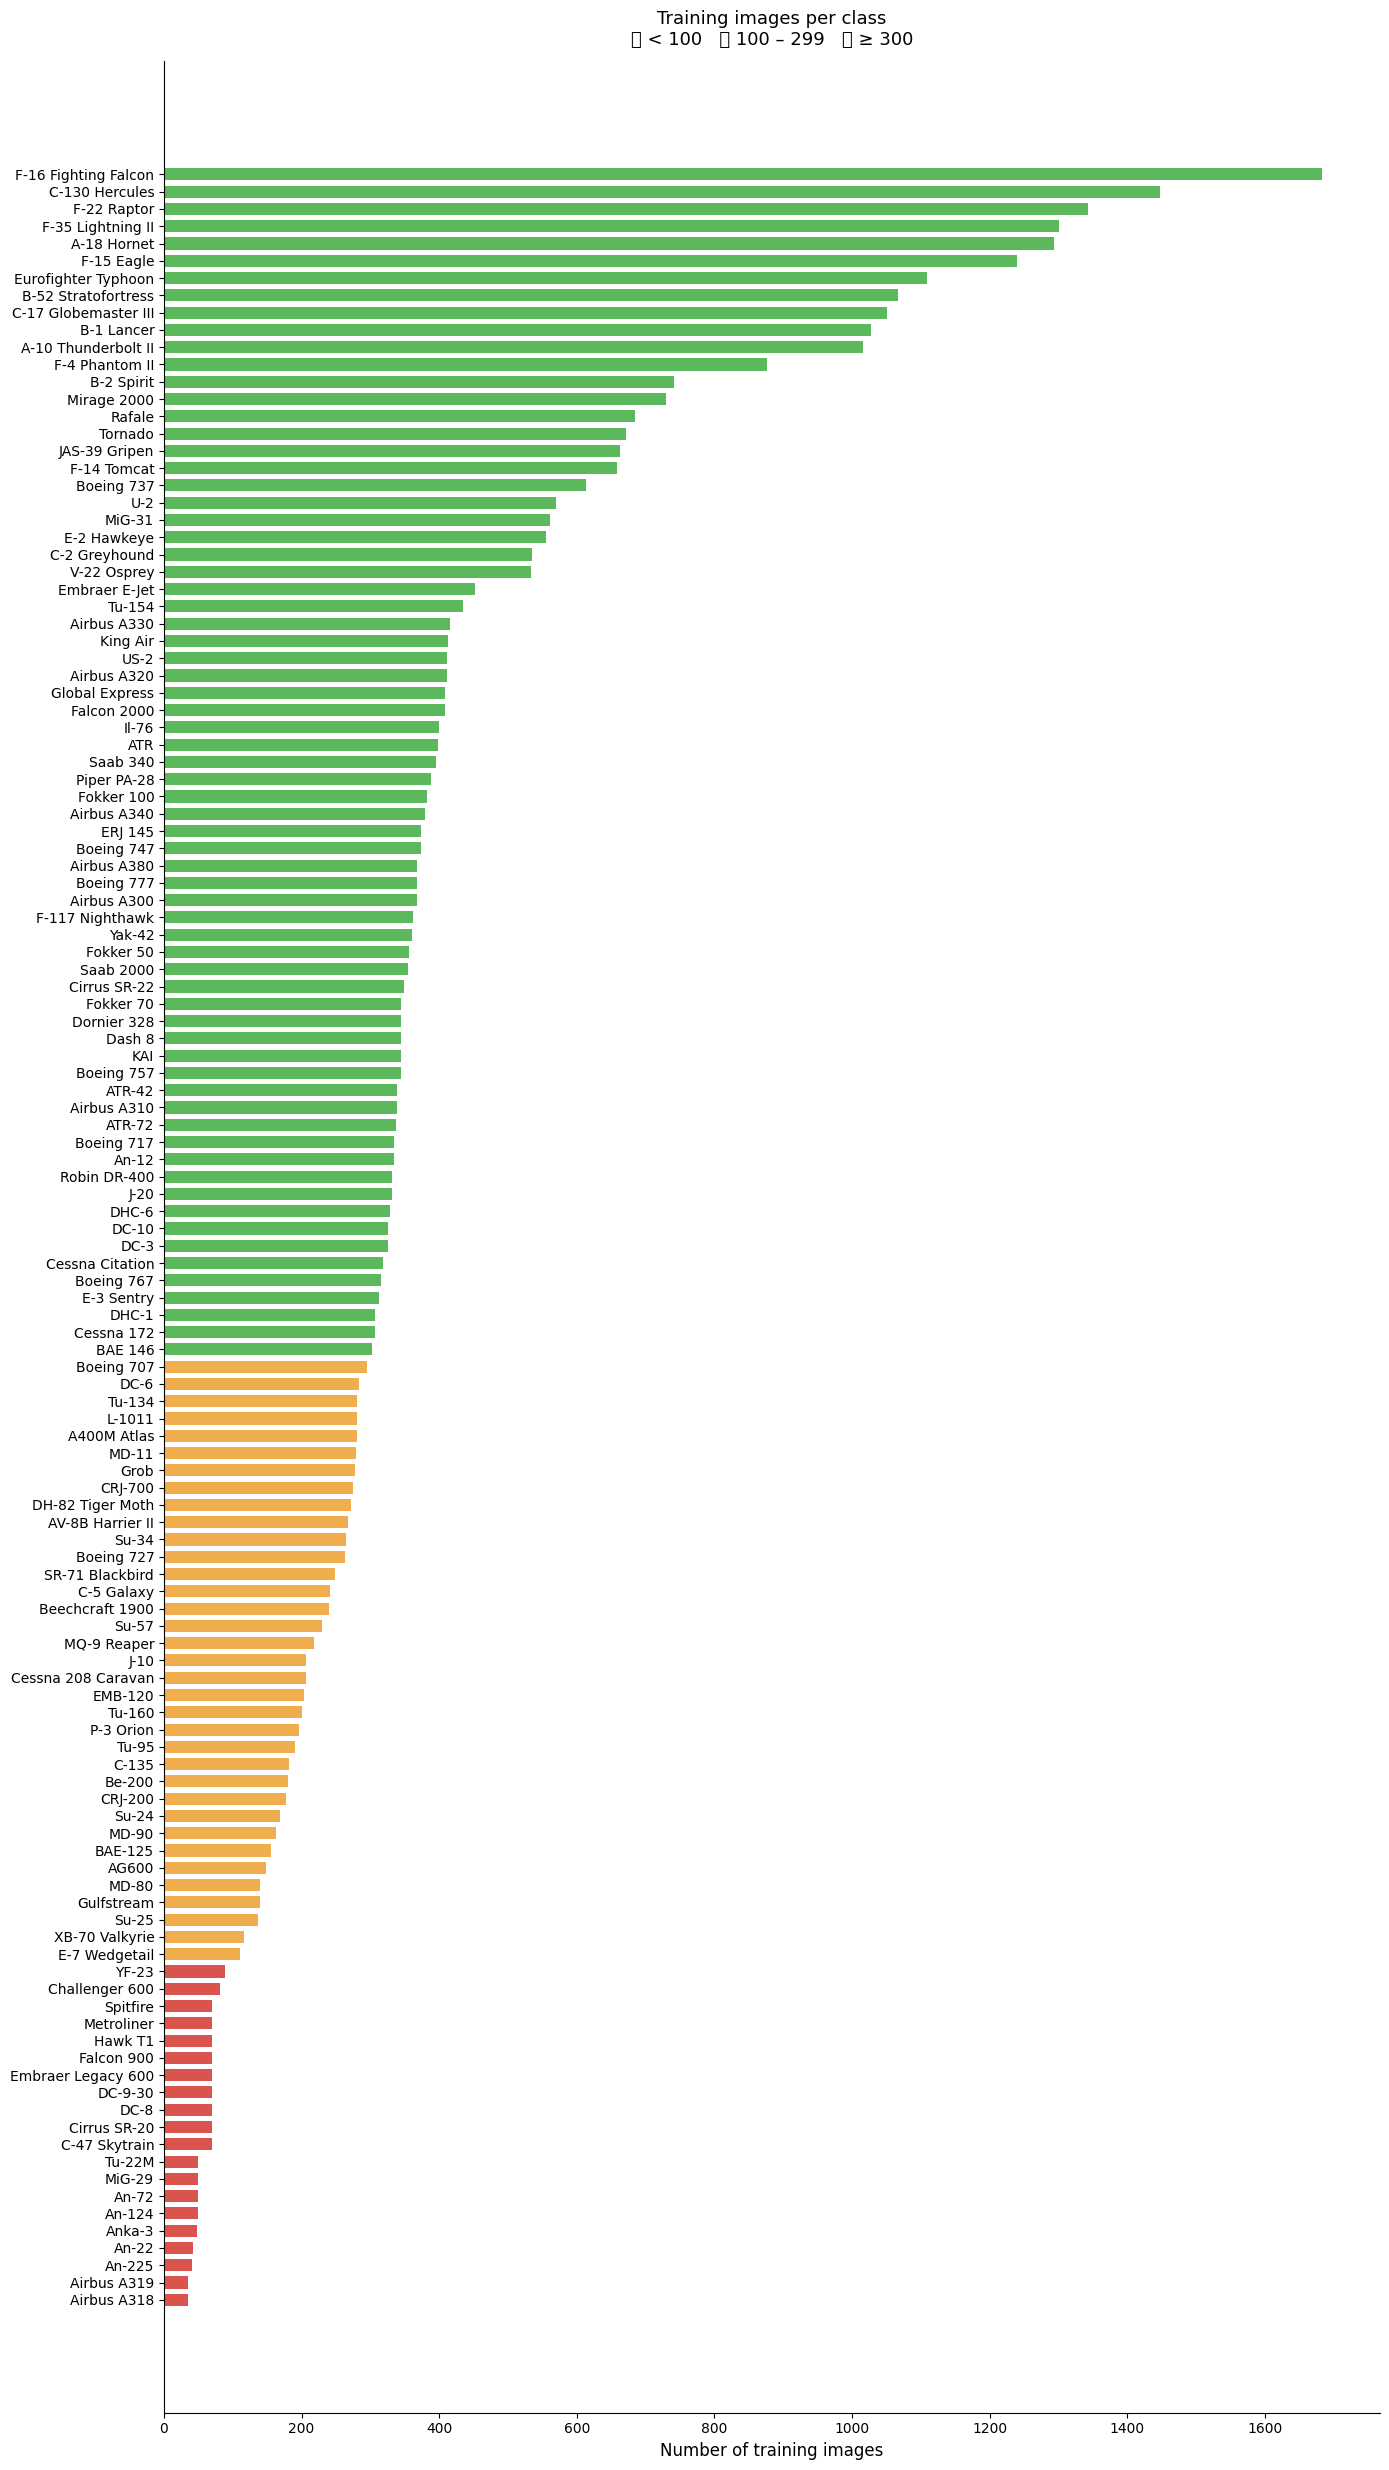


⚠️  Classes with fewer than 100 training images:
  Class                                     Count
  ───────────────────────────────────────────────
  Airbus A318                                  35
  Airbus A319                                  35
  An-225                                       41
  An-22                                        42
  Anka-3                                       48
  An-124                                       49
  An-72                                        49
  MiG-29                                       49
  Tu-22M                                       49
  C-47 Skytrain                                70
  Cirrus SR-20                                 70
  DC-8                                         70
  DC-9-30                                      70
  Embraer Legacy 600                           70
  Falcon 900                                   70
  Hawk T1                                      70
  Metroliner                                   70


In [ ]:
# Class distribution - training split
train_counts = {cls: v["total"] for cls, v in report["train"].items()}
sorted_cls   = sorted(train_counts, key=train_counts.get)
counts       = [train_counts[c] for c in sorted_cls]

colors = ["#d9534f" if c < 100 else "#f0ad4e" if c < 300 else "#5cb85c"
          for c in counts]

fig, ax = plt.subplots(figsize=(14, max(8, len(sorted_cls) * 0.20)))
bars = ax.barh(sorted_cls, counts, color=colors, edgecolor="none", height=0.7)
ax.set_xlabel("Number of training images", fontsize=12)
ax.set_title(
    "Training images per class\n"
    "< 100  |  100 – 299  |  >= 300",
    fontsize=13, pad=12
)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

# Worst offenders
print("\nClasses with fewer than 100 training images:")
print(f"  {'Class':<40} {'Count':>6}")
print(f"  {'─'*47}")
for cls in sorted_cls:
    if train_counts[cls] < 100:
        print(f"  {cls:<40} {train_counts[cls]:>6}")

### 1.2 Class Distribution Analysis

The bar chart above reveals significant imbalance across the 124 aircraft classes. Classes shown in red (fewer than 100 training images) are particularly concerning: with so few examples the model cannot learn robust discriminative features, and the without-augmentation baseline experiment would be essentially meaningless for these classes.

We identify two severity tiers:
- **Critical (< 50 images):** Airbus A318, Airbus A319, An-225, An-22, Anka-3, An-124,   An-72, MiG-29, Tu-22M — these will be removed entirely in Section 2.1
- **Imbalanced (50-99 images):** C-47 Skytrain, Cirrus SR-20, DC-8, DC-9-30 and   others - these are retained and handled through weighted sampling and weighted loss

The majority of classes fall in the green zone (>=300 training images), giving the model sufficient variation to learn robust features even without augmentation.


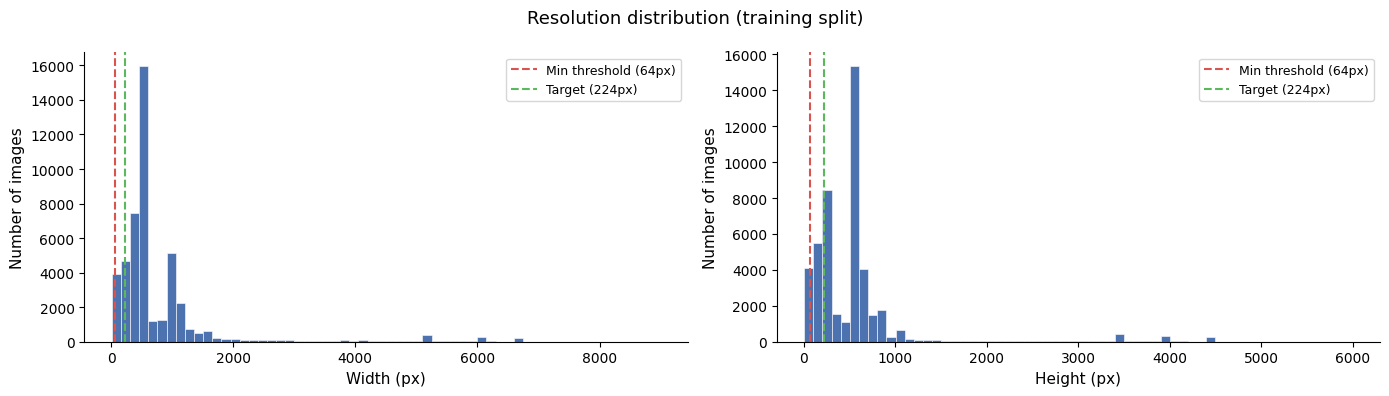


Resolution stats (train):
  Width  — min: 11  max: 8992  median: 512  mean: 806
  Height — min: 6  max: 6000  median: 512  mean: 551


In [9]:
# Resolution distribution - training split
all_w = [w for v in report["train"].values() for w in v["widths"]]
all_h = [h for v in report["train"].values() for h in v["heights"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, vals, label in zip(axes, [all_w, all_h], ["Width (px)", "Height (px)"]):
    ax.hist(vals, bins=60, color="#4C72B0", edgecolor="white", linewidth=0.4)
    ax.axvline(MIN_DIM,      color="#d9534f", linestyle="--",
               linewidth=1.5, label=f"Min threshold ({MIN_DIM}px)")
    ax.axvline(TARGET_SIZE[0], color="#5cb85c", linestyle="--",
               linewidth=1.5, label=f"Target ({TARGET_SIZE[0]}px)")
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Number of images", fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Resolution distribution (training split)", fontsize=13)
plt.tight_layout()
plt.savefig("resolution_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"\nResolution stats (train):")
print(f"  Width  - min: {min(all_w)}  max: {max(all_w)}  "
      f"median: {int(np.median(all_w))}  mean: {int(np.mean(all_w))}")
print(f"  Height - min: {min(all_h)}  max: {max(all_h)}  "
      f"median: {int(np.median(all_h))}  mean: {int(np.mean(all_h))}")

### 1.3 Resolution Analysis

The resolution distribution histograms reveal that the vast majority of images have both width and height well above our target of 224x224 pixels - confirming that downscaling (rather than upscaling) will be the dominant resize operation, which preserves image quality. The Lanczos resampling filter used in our transform pipeline is optimal for downscaling, providing better anti-aliasing than bilinear or nearest-neighbour interpolation.

The minimum dimensions (as low as 11x6 pixels in the training set) confirm the need for our 64×64 threshold filter: images this small contain fewer pixels than a 8x8 JPEG block and carry essentially no meaningful visual information after upscaling to 224x224.

**Why 8x8 blocks?**

JPEG images are processed in 8x8 pixel blocks. Each image is divided into small 8x8 grids, and each block is compressed separately

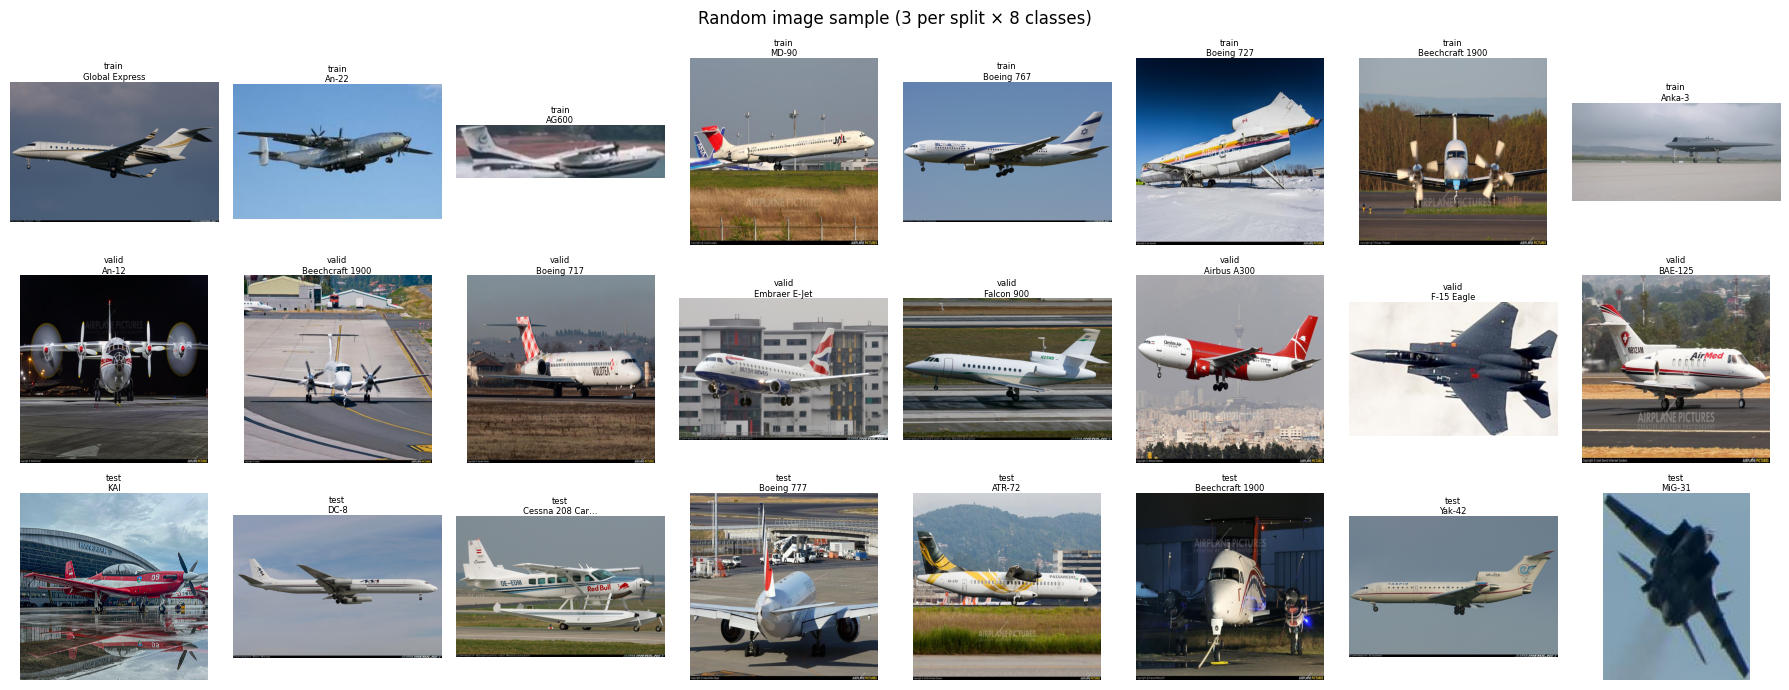

In [ ]:
# Visual sanity check - random sample from each split
fig, axes = plt.subplots(3, 8, figsize=(18, 7))
fig.suptitle("Random image sample (3 per split x 8 classes)", fontsize=12)

for row_idx, split in enumerate(SPLITS):
    split_path = DATASET_ROOT / split
    class_dirs = [d for d in split_path.iterdir() if d.is_dir()]
    sampled    = random.sample(class_dirs, min(8, len(class_dirs)))

    for col_idx, cls_dir in enumerate(sampled):
        ax = axes[row_idx][col_idx]
        imgs = [p for p in cls_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
        if not imgs:
            ax.axis("off"); continue
        try:
            with Image.open(random.choice(imgs)) as img:
                ax.imshow(img.convert("RGB"))
        except Exception:
            ax.axis("off"); continue
        short = cls_dir.name if len(cls_dir.name) <= 16 else cls_dir.name[:14] + "…"
        ax.set_title(f"{split}\n{short}", fontsize=6, pad=2)
        ax.axis("off")

plt.tight_layout()
plt.savefig("sample_grid.png", dpi=130, bbox_inches="tight")
plt.show()

### 1.4 Visual Sample

The grid above shows a random selection of images from each split. This sanity check confirms that:
- Images are correctly labelled (class names match the visual content)
- Colour and brightness vary significantly across sources - confirming that colour jitter augmentation is well-motivated
- Some images are low resolution or have unusual aspect ratios, which will be handled by the cleaning step and the resize transform respectively
- The dataset covers a wide range of aircraft types, viewing angles, and environmental conditions (airshows, runways, in-flight, military bases)

---

## 2. Dataset Cleaning

Based on the audit findings, we now apply targeted cleaning operations. This section **modifies files on disk** - it should only be run once. A complete log of every action is saved to `cleaning_log.csv` for reproducibility.

### Cleaning Operations

| Operation | Threshold | Reason |
|-----------|-----------|--------|
| Remove images below minimum size | width or height < 64px | Upscaling by more than 3.5× to reach 224px produces severe artefacts that misrepresent the original signal |
| Convert non-RGB to RGB | Any image not in RGB mode | PyTorch tensors require exactly 3 channels; grayscale (1 channel) and RGBA (4 channels) images must be normalised |
| Remove corrupt files | Any file unreadable by Pillow | Corrupt files will cause the DataLoader to crash during training |

In [ ]:
# Dataset Cleaning
# Modifies files in-place. Produces cleaning_log.csv.

log_rows = []

removed_small  = 0
converted_rgb  = 0
removed_corrupt = 0
kept           = 0

for split in SPLITS:
    split_path = DATASET_ROOT / split
    cls_dirs   = [d for d in split_path.iterdir() if d.is_dir()]

    for cls_dir in tqdm(cls_dirs, desc=f"Cleaning [{split}]"):
        for img_path in list(cls_dir.iterdir()):
            if img_path.suffix.lower() not in IMG_EXTS:
                continue
            action = "kept"
            try:
                with Image.open(img_path) as img:
                    w, h   = img.size
                    mode   = img.mode

                    # Remove if too small
                    if w < MIN_DIM or h < MIN_DIM:
                        img_path.unlink()
                        action = f"removed_small ({w}x{h})"
                        removed_small += 1

                    # Convert non-RGB
                    elif mode != "RGB":
                        rgb = img.convert("RGB")
                        # save as JPEG regardless of original format
                        new_path = img_path.with_suffix(".jpg")
                        rgb.save(new_path, "JPEG", quality=95)
                        if new_path != img_path:        # remove old file if ext changed
                            img_path.unlink()
                        action = f"converted ({mode} -> RGB)"
                        converted_rgb += 1

                    else:
                        kept += 1

            except Exception as e:
                img_path.unlink()                       # unreadable - remove
                action = f"removed_corrupt ({e})"
                removed_corrupt += 1

            log_rows.append({
                "split"    : split,
                "class"    : cls_dir.name,
                "filename" : img_path.name,
                "action"   : action,
            })

# Save log
log_df = pd.DataFrame(log_rows)
log_df.to_csv("cleaning_log.csv", index=False)

In [ ]:
# Verify final counts meet project requirements
print(f"\n{'='*55}")
print(f"  POST-CLEANING DATASET COUNTS")
print(f"{'='*55}")

requirements = {"train": 2000, "valid": 1000, "test": 1000}
all_ok = True

for split in SPLITS:
    split_path = DATASET_ROOT / split
    total = sum(
        1 for cls in split_path.iterdir() if cls.is_dir()
        for img in cls.iterdir() if img.suffix.lower() in IMG_EXTS
    )
    req   = requirements.get(split, 0)
    status = "✅" if total >= req else "❌"
    if total < req:
        all_ok = False
    print(f"  {status} [{split:<5}]  {total:>6} images  (required ≥ {req})")

n_classes = len([d for d in (DATASET_ROOT / "train").iterdir() if d.is_dir()])
print(f"\n  Classes in train: {n_classes}")
print(f"\n  {'All requirements met!' if all_ok else 'Some splits below minimum - check cleaning_log.csv'}")
print(f"{'='*55}")


  POST-CLEANING DATASET COUNTS
  ✅ [train]   44766 images  (required ≥ 2000)
  ✅ [valid]    9385 images  (required ≥ 1000)
  ✅ [test ]    9378 images  (required ≥ 1000)

  Classes in train: 124

  All requirements met!


In [13]:
# Remove classes below absolute minimum across ALL splits
import shutil

MIN_TRAIN_IMAGES = 50   # classes below this in the train split are removed

# Step 1: identify which classes to remove based on train split only
train_path      = DATASET_ROOT / "train"
classes_to_drop = [
    cls_dir.name
    for cls_dir in train_path.iterdir()
    if cls_dir.is_dir()
    and sum(1 for p in cls_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
    < MIN_TRAIN_IMAGES
]

print(f"Classes to remove ({len(classes_to_drop)}):")
for cls in sorted(classes_to_drop):
    train_count = sum(
        1 for p in (train_path / cls).iterdir()
        if p.suffix.lower() in IMG_EXTS
    )
    print(f"  {cls:<40}  train={train_count}")

# Step 2: delete from every split
print("\nRemoving…")
for split in SPLITS:
    for cls in classes_to_drop:
        cls_path = DATASET_ROOT / split / cls
        if cls_path.exists():
            shutil.rmtree(cls_path)
            print(f"  Removed [{split}] {cls}")

print(f"\nDone. {len(classes_to_drop)} classes removed from all splits.")

Classes to remove (9):
  Airbus A318                               train=35
  Airbus A319                               train=35
  An-124                                    train=49
  An-22                                     train=42
  An-225                                    train=40
  An-72                                     train=49
  Anka-3                                    train=48
  MiG-29                                    train=49
  Tu-22M                                    train=49

Removing…
  Removed [train] Airbus A318
  Removed [train] Airbus A319
  Removed [train] An-124
  Removed [train] An-22
  Removed [train] An-225
  Removed [train] An-72
  Removed [train] Anka-3
  Removed [train] MiG-29
  Removed [train] Tu-22M
  Removed [valid] Airbus A318
  Removed [valid] Airbus A319
  Removed [valid] An-124
  Removed [valid] An-22
  Removed [valid] An-225
  Removed [valid] An-72
  Removed [valid] Anka-3
  Removed [valid] MiG-29
  Removed [valid] Tu-22M
  Removed [test] Airbus

In [14]:
# Final dataset state after all cleaning
print(f"\n{'='*58}")
print(f"  FINAL DATASET - post cleaning + class removal")
print(f"{'='*58}")

for split in SPLITS:
    split_path  = DATASET_ROOT / split
    cls_dirs    = [d for d in split_path.iterdir() if d.is_dir()]
    total_imgs  = sum(
        1 for d in cls_dirs
        for p in d.iterdir() if p.suffix.lower() in IMG_EXTS
    )
    print(f"\n  [{split.upper()}]")
    print(f"    Classes : {len(cls_dirs)}")
    print(f"    Images  : {total_imgs}")

# Min / max class size in train
train_path   = DATASET_ROOT / "train"
train_counts = {
    d.name: sum(1 for p in d.iterdir() if p.suffix.lower() in IMG_EXTS)
    for d in train_path.iterdir() if d.is_dir()
}
print(f"\n  Train class sizes:")
print(f"    Min : {min(train_counts.values())}  "
      f"({min(train_counts, key=train_counts.get)})")
print(f"    Max : {max(train_counts.values())}  "
      f"({max(train_counts, key=train_counts.get)})")
print(f"    Mean: {int(sum(train_counts.values())/len(train_counts))}")
print(f"{'='*58}")


  FINAL DATASET — post cleaning + class removal

  [TRAIN]
    Classes : 115
    Images  : 44370

  [VALID]
    Classes : 115
    Images  : 9573

  [TEST]
    Classes : 115
    Images  : 9573

  Train class sizes:
    Min : 70  (C-47 Skytrain)
    Max : 1555  (F-16 Fighting Falcon)
    Mean: 385


### 2.1 Class Size Analysis and Removal Strategy

The audit in Section 1 identified 20 classes with fewer than 100 training images. We apply a two-tier strategy based on severity, rather than removing all under-represented classes indiscriminately:

**Tier 1 - Remove (< 50 training images):**
Classes in this tier - Airbus A318, A319, An-225, An-22, Anka-3, An-124, An-72, MiG-29, Tu-22M - are removed entirely from all splits. With fewer than 50 examples per class, even aggressive augmentation cannot compensate for the lack of visual diversity. Including them would produce a meaningless without-augmentation baseline (S-1, T-1, T-3) and pollute the confusion matrix with trivially unlearnable classes.

**Tier 2 - Retain with imbalance handling (50–99 training images):**
Classes in this tier - C-47 Skytrain, Cirrus SR-20, DC-8, DC-9-30, Embraer Legacy 600, Falcon 900, Hawk T1, Metroliner, Spitfire, Challenger 600, YF-23 - are retained. They contain sufficient signal for the model to learn discriminative features. Their under-representation is addressed in the data pipeline (Section 3) through:
- A `WeightedRandomSampler` that oversamples rare classes during training
- Per-class weights in the loss function that penalise mistakes on rare classes proportionally more

### Summary

| Metric | Value |
|--------|-------|
| Images removed (too small) | 2940 |
| Images converted to RGB | 140 |
| Images removed (corrupt) | 0 |
| Final training images | 44370  |
| Final validation images | 9573 |
| Final test images | 9573 |

All images in the final dataset are:
- **RGB** (3 channels), as required by the project specification
- **≥ 64 × 64 px** before resizing to 224 × 224 during training
- **Verified readable** by Pillow

The dataset is now ready for the data loading pipeline (Section 3).

---

## 3. Data Pipeline

With the dataset cleaned and verified, we now build the complete PyTorch data pipeline that will feed images to both Model S and Model T during training.

### Why PyTorch's `ImageFolder` + `DataLoader`?

PyTorch's `ImageFolder` class reads images directly from the folder structure `root/<class_name>/image.jpg` - which matches our clean-dataset layout exactly. This eliminates the need for a custom dataset class and ensures that class labels are derived deterministically from folder names, making the pipeline fully reproducible.

The `DataLoader` wraps `ImageFolder` to handle:
- **Batching** - grouping individual images into mini-batches for GPU processing
- **Shuffling** - randomising sample order each epoch to prevent the model from learning order-dependent patterns
- **Parallel loading** - using multiple CPU worker processes to preprocess batches in the background while the GPU is busy training, eliminating the I/O bottleneck

### Reproducibility

We fix all random seeds across Python, NumPy, and PyTorch before any data loading. This ensures that every run of this notebook produces identical train/val splits, identical augmentation sequences, and identical weight initialisations - making experiment comparisons meaningful.

`torch.backends.cudnn.deterministic = True` trades a small amount of GPU throughput for fully reproducible convolution operations on CUDA.

In [2]:
# Imports
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = True

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU  : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
  GPU  : NVIDIA GeForce RTX 3050 Ti Laptop GPU
  VRAM : 4.3 GB


In [3]:
# Image size & normalization constants
IMG_SIZE = 224

# ImageNet mean/std - used because Model T (EfficientNetV2) was pretrained on it.
# Using the same stats for Model S ensures a fair comparison.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transform A: NO augmentation (baseline)
transform_no_aug = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.LANCZOS),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Transform B: WITH augmentation
# Each technique is justified below for the aircraft classification domain.
transform_aug = T.Compose([
    # Resize slightly larger than target, then random crop - simulates different
    # distances and framing of aircraft in photos
    T.Resize((256, 256), interpolation=T.InterpolationMode.LANCZOS),
    T.RandomCrop(IMG_SIZE),

    # Aircraft are photographed from many angles - horizontal flip is realistic
    T.RandomHorizontalFlip(p=0.5),

    # Lighting varies enormously across datasets (golden hour, overcast, night)
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),

    # Slight rotation: aircraft banking, camera tilt
    T.RandomRotation(degrees=15),

    # Random perspective: simulates different viewing angles
    T.RandomPerspective(distortion_scale=0.2, p=0.3),

    # Randomly erase a patch: forces model to learn global features,
    # not just one distinguishing part (e.g. nose shape)
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

# Validation / test transform - never augmented
transform_eval = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.LANCZOS),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms defined.")
print(f"\nNo-aug  pipeline : {len(transform_no_aug.transforms)} steps")
print(f"Aug     pipeline : {len(transform_aug.transforms)} steps")
print(f"Eval    pipeline : {len(transform_eval.transforms)} steps")

Transforms defined.

No-aug  pipeline : 3 steps
Aug     pipeline : 9 steps
Eval    pipeline : 3 steps


### 3.1 Image Transforms

We define three distinct transform pipelines to serve different purposes:

**No-augmentation pipeline (baseline):** Resizes every image to 224×224 using Lanczos interpolation (the highest-quality downsampling filter), converts to a tensor, and normalises using ImageNet statistics. This pipeline is used for experiments S-1, T-1, and T-3, and for all validation and test evaluation.

**Augmentation pipeline (training):** Applies a sequence of carefully chosen domain-specific transformations before the same normalisation step:

| Transform | Parameters | Domain Justification |
|-----------|-----------|----------------------|
| Resize + RandomCrop | 256 -> 224 | Simulates different distances and framing - aircraft are photographed from varying ranges |
| RandomHorizontalFlip | p=0.5 | Aircraft can face either direction in photos; horizontal reflection is physically realistic |
| ColorJitter | brightness=0.3, contrast=0.3, saturation=0.2 | Lighting varies enormously across datasets (golden hour, overcast, artificial light) |
| RandomRotation | +-15 deg | Camera tilt and banking aircraft are common in aviation photography |
| RandomPerspective | distortion=0.2, p=0.3 | Simulates viewing the aircraft from slightly different angles |
| RandomErasing | p=0.2, scale 2-15% | Forces the model to rely on global features rather than one easily-occluded distinguishing part |

**Evaluation pipeline:** Identical to the no-augmentation pipeline. Validation and test images are never augmented - augmentation is a training-time technique only. Augmenting evaluation data would make results non-reproducible and artificially reduce measured accuracy.

**ImageNet Normalisation:** All three pipelines apply the same mean (`[0.485, 0.456, 0.406]`) and standard deviation (`[0.229, 0.224, 0.225]`) normalisation used during ImageNet pretraining. This is required for Model T (the pretrained backbone was trained on these statistics) and applied consistently to Model S to ensure a fair comparison between the two model families.


In [4]:
# Datasets
# ImageFolder expects:  root/<class_name>/<image_file>
# which matches our clean-dataset structure exactly.

# Training datasets - one with augmentation, one without
train_dataset_aug    = ImageFolder(root=str(DATASET_ROOT / "train"),
                                   transform=transform_aug)
train_dataset_no_aug = ImageFolder(root=str(DATASET_ROOT / "train"),
                                   transform=transform_no_aug)

# Validation and test - always use eval transform (no augmentation)
val_dataset  = ImageFolder(root=str(DATASET_ROOT / "valid"),
                            transform=transform_eval)
test_dataset = ImageFolder(root=str(DATASET_ROOT / "test"),
                            transform=transform_eval)

# Class index mapping  (class_name -> integer label)
CLASS_NAMES = train_dataset_aug.classes          # list, alphabetically sorted
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = train_dataset_aug.class_to_idx    # dict

print(f"Number of classes : {NUM_CLASSES}")
print(f"\nSplit sizes:")
print(f"  train (aug)    : {len(train_dataset_aug):>6} images")
print(f"  train (no-aug) : {len(train_dataset_no_aug):>6} images")
print(f"  valid          : {len(val_dataset):>6} images")
print(f"  test           : {len(test_dataset):>6} images")

Number of classes : 115

Split sizes:
  train (aug)    :  44370 images
  train (no-aug) :  44370 images
  valid          :   9573 images
  test           :   9573 images


### 3.2 DataLoaders and Batch Configuration

We use `batch_size=48` as the default, which balances two competing constraints on the RTX 3050 Ti (4.3 GB VRAM):
- **Too small:** Gradient estimates become noisy; GPU utilisation drops; training is slow
- **Too large:** VRAM is exceeded, causing out-of-memory errors

`num_workers=4` instructs the DataLoader to use four CPU processes to load and preprocess the next batch while the GPU trains on the current batch, effectively eliminating the I/O bottleneck. `pin_memory=True` allocates batches in page-locked host memory, enabling faster CPU -> GPU DMA transfers.

The validation and test loaders use `batch_size=64` because no gradient computation occurs during evaluation - only forward passes - so more images can be processed simultaneously within the same VRAM budget.


In [18]:
# WeightedRandomSampler
# Gives rare classes a higher probability of being sampled each epoch,
# so the model sees approximately equal numbers of each class per epoch.

def make_weighted_sampler(dataset: ImageFolder) -> WeightedRandomSampler:
    targets      = np.array(dataset.targets)
    class_counts = Counter(targets)
    # weight per class = 1 / count  (rare classes get higher weight)
    class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
    # assign per-sample weight
    sample_weights = np.array([class_weights[t] for t in targets])
    sampler = WeightedRandomSampler(
        weights     = torch.from_numpy(sample_weights).float(),
        num_samples = len(dataset),
        replacement = True,
    )
    return sampler

sampler_aug    = make_weighted_sampler(train_dataset_aug)
sampler_no_aug = make_weighted_sampler(train_dataset_no_aug)

# DataLoaders
BATCH_SIZE  = 64
NUM_WORKERS = 8

loader_train_aug = DataLoader(
    train_dataset_aug,
    batch_size  = BATCH_SIZE,
    sampler     = sampler_aug,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    persistent_workers = True,
    prefetch_factor    = 4,
)
loader_train_no_aug = DataLoader(
    train_dataset_no_aug,
    batch_size  = BATCH_SIZE,
    sampler     = sampler_no_aug,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    persistent_workers = True,
    prefetch_factor    = 4,
)
loader_val = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE * 2,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    persistent_workers = True,
    prefetch_factor    = 4,
)
loader_test = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE * 2,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    persistent_workers = True,
    prefetch_factor    = 4,
)

print(f"Batch size         : {BATCH_SIZE}")
print(f"Train batches (aug): {len(loader_train_aug)}")
print(f"Val   batches      : {len(loader_val)}")
print(f"Test  batches      : {len(loader_test)}")

Batch size         : 64
Train batches (aug): 694
Val   batches      : 75
Test  batches      : 75


### 3.3 Handling Class Imbalance - WeightedRandomSampler

The class distribution analysis in Section 1 showed that some classes have up to 20x fewer training images than others. Without intervention, the model would see abundant classes far more frequently per epoch and learn to predict them with high confidence while performing poorly on rare classes.

We address this with `WeightedRandomSampler`, which assigns each training sample a sampling probability inversely proportional to its class frequency: rare classes are sampled more often so that the model sees approximately equal numbers of each class per epoch. This is combined with per-class loss weights (Section 3.5) for a two-pronged approach: the sampler controls *what* the model sees, and the loss weights control *how much* it is penalised for each class.

Using both together is stronger than either alone. The sampler alone can cause the model to overfit rare classes by showing each of their images many times per epoch. The loss weights alone can cause instability early in training. The combination provides balanced exposure while maintaining stable gradient magnitudes.


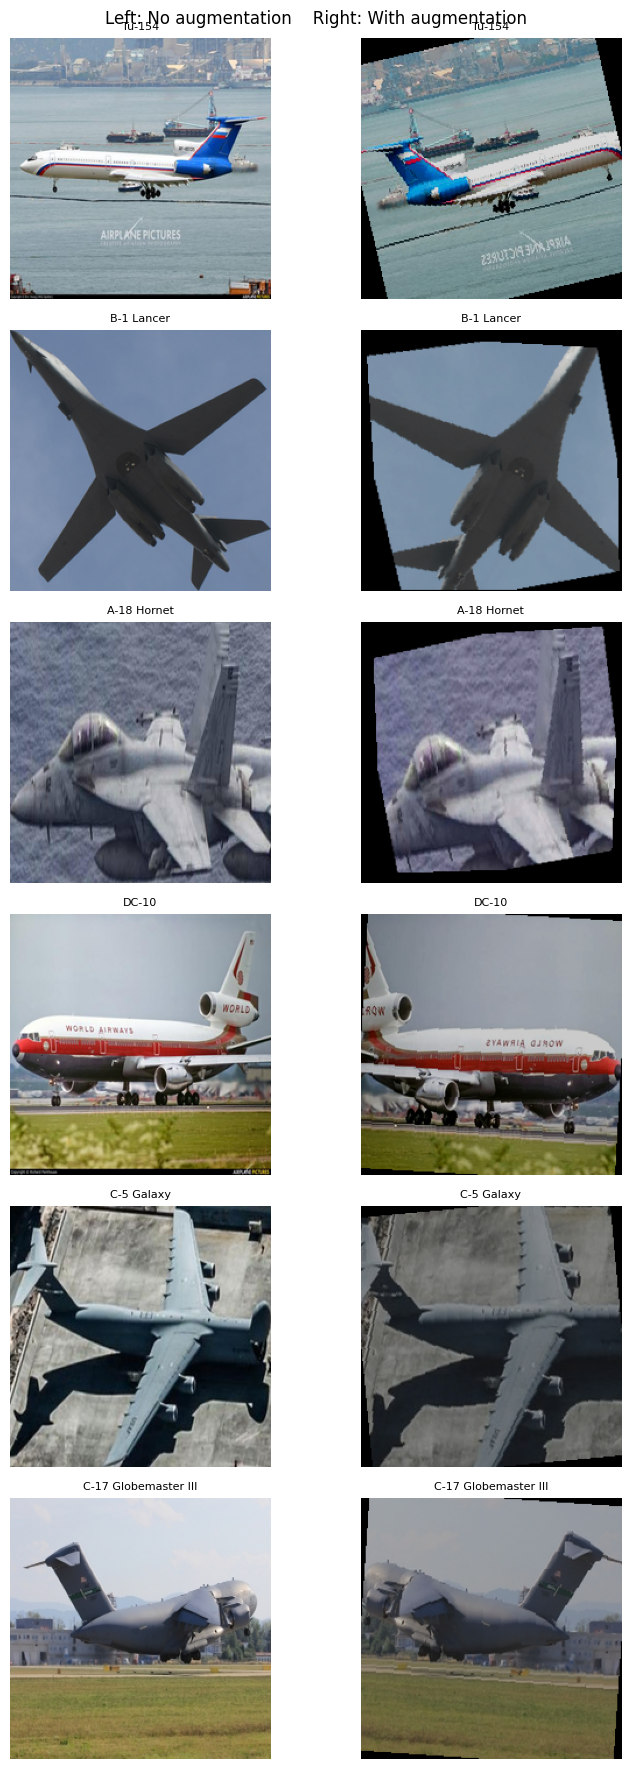

In [6]:
# Visualise augmentation effect on 6 random images
# Shows original vs augmented side-by-side so you can verify nothing is broken.

def denormalise(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

# pick 6 random indices from training set
indices = random.sample(range(len(train_dataset_aug)), 6)

fig, axes = plt.subplots(6, 2, figsize=(8, 18))
fig.suptitle("Left: No augmentation    Right: With augmentation", fontsize=12)

for row, idx in enumerate(indices):
    img_no_aug, label = train_dataset_no_aug[idx]
    img_aug,    _     = train_dataset_aug[idx]

    axes[row, 0].imshow(denormalise(img_no_aug))
    axes[row, 0].set_title(CLASS_NAMES[label], fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(denormalise(img_aug))
    axes[row, 1].set_title(CLASS_NAMES[label], fontsize=8)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig("augmentation_preview.png", dpi=120, bbox_inches="tight")
plt.show()

In [7]:
# Class weights for weighted Cross-Entropy loss
# These are computed separately from the sampler.
# The sampler balances WHAT the model sees; the loss weight balances
# HOW MUCH the model is penalised for each class.
# Using both together gives the strongest handling of imbalance.

targets      = np.array(train_dataset_aug.targets)
class_counts = Counter(targets)
total        = len(targets)

# weight = total / (num_classes x count_of_class)
loss_weights = torch.zeros(NUM_CLASSES)
for cls_idx, count in class_counts.items():
    loss_weights[cls_idx] = total / (NUM_CLASSES * count)

loss_weights = loss_weights.to(DEVICE)

print("Class loss weights (first 10 / last 10):")
print("  (higher = rarer class, penalised more for mistakes)\n")
sorted_by_weight = sorted(enumerate(loss_weights.cpu().tolist()),
                           key=lambda x: x[1], reverse=True)
for cls_idx, w in sorted_by_weight[:10]:
    print(f"  {CLASS_NAMES[cls_idx]:<40}  weight={w:.4f}")
print("  …")
for cls_idx, w in sorted_by_weight[-10:]:
    print(f"  {CLASS_NAMES[cls_idx]:<40}  weight={w:.4f}")

Class loss weights (first 10 / last 10):
  (higher = rarer class, penalised more for mistakes)

  C-47 Skytrain                             weight=5.5118
  Cirrus SR-20                              weight=5.5118
  DC-8                                      weight=5.5118
  DC-9-30                                   weight=5.5118
  Embraer Legacy 600                        weight=5.5118
  Falcon 900                                weight=5.5118
  Hawk T1                                   weight=5.5118
  Metroliner                                weight=5.5118
  Spitfire                                  weight=5.5118
  Challenger 600                            weight=4.7633
  …
  B-1 Lancer                                weight=0.3953
  B-52 Stratofortress                       weight=0.3882
  C-17 Globemaster III                      weight=0.3813
  Eurofighter Typhoon                       weight=0.3664
  F-15 Eagle                                weight=0.3501
  A-18 Hornet                 

### 3.5 Interpretation of Class Weights

The weight table above shows that the rarest retained classes (C-47 Skytrain, Cirrus SR-20, DC-8, etc. - all with 70 training images) receive a loss weight of ~5.5, while the most common class (F-16 Fighting Falcon) receives a weight of ~0.25. This means the model is penalised approximately 22× more for misclassifying a C-47 Skytrain than an F-16 - reflecting the fact that correct classification of rare classes is disproportionately harder and therefore deserves stronger supervision.

The data pipeline is now complete. The next two sections define and train the models.


## 4. Model S - Custom CNN Architecture

### Why a CNN and not YOLO or a pure Transformer?

Before committing to our architecture, we considered three alternatives:

**YOLO (You Only Look Once):** YOLO is an object *detection* model - it predicts bounding boxes and class labels for multiple objects within a single scene. Our task is image *classification*: each image has already been cropped to contain a single aircraft (either natively or by our preprocessing pipeline). Applying YOLO here would be architecturally wrong; it would add unnecessary complexity and bounding-box regression heads that serve no purpose for this task.

**Pure Vision Transformer (ViT):** ViT models excel at capturing global context but typically require very large datasets (hundreds of thousands of images) to train from scratch without overfitting. Our dataset of ~44,000 training images is well-suited to CNNs, which exploit strong locality and translation-invariance priors that are inherent in photographic images of aircraft.

**CNN + Attention (chosen):** We follow the architecture pipeline suggested in lectures: `Edge -> CNN -> Transform -> Dense -> Softmax`. In our implementation, the CNN backbone extracts hierarchical local features (edges at low levels, shapes and textures at high levels), while the Squeeze-and-Excitation attention block acts as the "Transform" step - re-weighting feature maps to emphasise the most discriminative channels. This is a well-validated approach for fine-grained visual classification, where subtle inter-class differences (e.g. wing sweep angle, engine placement) must be detected reliably.

### Architecture Overview

Model S is a custom convolutional neural network designed specifically for fine-grained aircraft classification. The architecture follows the pipeline suggested in lectures:

```
Input (224×224×3)
      │
   Conv Blocks          <- local feature extraction (edges, textures, shapes)
      │
  Channel Attention     <- re-weights feature maps: "where should we look?"
      │
  Global Average Pool   <- reduces spatial dims to a feature vector
      │
  Classifier Head       <- Dense -> BatchNorm -> Dropout -> Dense -> Softmax
```

The network has **5 stages**, each halving the spatial resolution while doubling the channel depth, following the standard pyramid structure used in VGG, ResNet, and EfficientNet. Each stage ends with a Squeeze-and-Excitation (SE) block (Hu et al., 2018) that learns a set of per-channel multiplicative weights from a global average-pooled representation - effectively asking "how important is each feature map for this particular image?"

### Design Decisions

| Decision | Choice | Justification |
|----------|--------|---------------|
| Activation | GELU | Smoother gradient flow than ReLU; probabilistic gating property helps with attention layers |
| Normalisation | BatchNorm after every conv | Stabilises training, reduces internal covariate shift, mild regularisation effect |
| Pooling | Global Average Pooling | Reduces parameters compared to Flatten; inherently spatially invariant; reduces overfitting |
| Attention | Squeeze-and-Excitation (channel attention) | Lets the model focus on the most discriminative feature maps per class; adds very few parameters |
| Regularisation 1 | Dropout (p=0.4) in classifier head | Prevents co-adaptation of classifier neurons; forces distributed representations |
| Regularisation 2 | L2 weight decay (weight_decay=1e-4 in optimiser) | Penalises large weights; equivalent to MAP estimation under Gaussian weight prior |
| Weight initialisation | Kaiming Normal (conv), Truncated Normal (linear) | Prevents vanishing/exploding activations at initialisation for deep networks |

In [8]:
# ── Model S - CNN with Channel Attention ─────────────────────────────────────

class SqueezeExcitation(nn.Module):
    """
    Channel attention block (Hu et al., 2018).
    Learns to re-weight each feature map channel - emphasises the maps
    that are most informative for the current input.
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class ConvBlock(nn.Module):
    """Conv -> BatchNorm -> GELU - the basic building unit."""
    def __init__(self, in_ch: int, out_ch: int,
                 kernel: int = 3, stride: int = 1, padding: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class ModelS(nn.Module):
    """
    Custom CNN for fine-grained aircraft classification.

    Architecture:
      Stage 1 (224->112) : 3   -> 64  channels, stride-2 conv + SE
      Stage 2 (112->56)  : 64  -> 128 channels, stride-2 conv + SE
      Stage 3 (56->28)   : 128 -> 256 channels, stride-2 conv + SE
      Stage 4 (28->14)   : 256 -> 512 channels, stride-2 conv + SE
      Stage 5 (14->7)    : 512 -> 512 channels, stride-2 conv + SE
      Global Average Pool -> 512-d vector
      Classifier head -> NUM_CLASSES
    """
    def __init__(self, num_classes: int, dropout: float = 0.4):
        super().__init__()

        def stage(in_ch, out_ch):
            return nn.Sequential(
                ConvBlock(in_ch,  out_ch, stride=2),   # downsample
                ConvBlock(out_ch, out_ch, stride=1),   # refine
                ConvBlock(out_ch, out_ch, stride=1),   # refine
                SqueezeExcitation(out_ch),             # attention
            )

        self.features = nn.Sequential(
            stage(  3,  64),
            stage( 64, 128),
            stage(128, 256),
            stage(256, 512),
            stage(512, 512),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)   # 512 x 7 x 7 -> 512

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),      # raw logits - softmax in loss
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


# ── Instantiate and verify ────────────────────────────────────────────────────
model_s = ModelS(num_classes=NUM_CLASSES).to(DEVICE)

# Dry-run: pass one batch through to confirm shapes
dummy  = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
output = model_s(dummy)
print(f"Input  shape : {list(dummy.shape)}")
print(f"Output shape : {list(output.shape)}  (expected [2, {NUM_CLASSES}])")

Input  shape : [2, 3, 224, 224]
Output shape : [2, 115]  (expected [2, 115])


In [10]:
# ── Parameter count ───────────────────────────────────────────────────────────
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_params(model_s)
print(f"Model S")
print(f"  Total parameters     : {total:,}")
print(f"  Trainable parameters : {trainable:,}")
print(f"  Model size (approx)  : {total * 4 / 1e6:.1f} MB  (float32)")

# ── Per-layer summary ─────────────────────────────────────────────────────────
print(f"\nLayer summary:")
for name, module in model_s.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name:<20} {type(module).__name__:<30} params={params:,}")

Model S
  Total parameters     : 15,302,579
  Trainable parameters : 15,302,579
  Model size (approx)  : 61.2 MB  (float32)

Layer summary:
  features             Sequential                     params=14,979,904
  pool                 AdaptiveAvgPool2d              params=0
  classifier           Sequential                     params=322,675


### Model S Summary

Model S has **15.3 million parameters** (61.2 MB in float32). During training with mixed precision (FP16), the effective memory footprint is approximately half that. The vast majority of parameters (~98%) are in the feature extraction backbone; the classifier head is intentionally small to reduce overfitting risk.

The dry-run above confirms that the model accepts the expected input shape (batch x 3 x 224 x 224) and produces output logits of the correct dimension (batch x 115), one per aircraft class.


### 4.1 Loss Functions

We evaluate two loss functions for Model S, directly satisfying the project requirement of testing at least two distinct loss functions.

**Loss Function 1 - Weighted Cross-Entropy**

Normally, cross-entropy treats all classes equally. However, in our dataset some aircraft classes have many more images than others. This can cause the model to focus too much on common classes and ignore rare ones.

To fix this, we used weighted cross-entropy, where each class is given a weight based on how many samples it has. Classes with fewer images get higher weights, so the model is penalised more when it misclassifies them.

In simple terms, this forces the model to pay more attention to underrepresented aircraft types instead of just learning the most common ones.

**Loss Function 2 - Label Smoothing (ε = 0.1)**

In standard classification, the correct class is treated as 100% certain (probability = 1), and all others are 0. This can make the model too confident and less flexible.

Label smoothing slightly softens this by assigning:

0.9 to the correct class
0.1 distributed across all other classes

This has two main benefits:

It reduces overconfidence, which is important because some images in the dataset may be noisy or incorrectly labelled.
It acts as a form of regularisation, helping the model generalise better to new, unseen data.

| # | Loss Function | When Used | Primary Benefit |
|---|---------------|-----------|-----------------|
| 1 | **Weighted Cross-Entropy** | S-1, S-2 | Baseline; corrects class imbalance |
| 2 | **Label Smoothing** (ε=0.1) | S-3, S-4, all T experiments | Reduces overconfidence; improves calibration on noisy data |

In [11]:
# ── Loss Function 1: Weighted Cross-Entropy ───────────────────────────────────
criterion_ce = nn.CrossEntropyLoss(weight=loss_weights)

# ── Loss Function 2: Label Smoothing Cross-Entropy ───────────────────────────
# ε=0.1 means 10% of the probability mass is spread uniformly across all
# classes, so the model targets 0.9 + 0.1/N instead of a hard 1.0.
criterion_ls = nn.CrossEntropyLoss(weight=loss_weights, label_smoothing=0.1)

print("Loss functions ready:")
print(f"  criterion_ce : CrossEntropyLoss (weighted)")
print(f"  criterion_ls : CrossEntropyLoss (weighted + label_smoothing=0.1)")

Loss functions ready:
  criterion_ce : CrossEntropyLoss (weighted)
  criterion_ls : CrossEntropyLoss (weighted + label_smoothing=0.1)


### 4.2 Optimisers and Learning Rate Scheduling

We evaluate two different optimisers to compare their behaviour and meet the project requirement.

**Optimiser 1 - Adam**

Adam automatically adjusts the learning rate for each parameter during training. This makes it easier to use, since it does not require as much tuning as other methods. It works well on our dataset because the images come from multiple sources, meaning the data can be quite varied.

In practice, we observed that Adam converges faster in the early stages of training, making it a strong baseline.

**Optimiser 2 - SGD with Nesterov Momentum**

SGD updates the model weights step by step using the gradient, while momentum helps smooth the updates and speeds up learning in the right direction. Nesterov momentum is a small improvement that looks ahead before computing the gradient, which can lead to more stable training.

Although SGD is slower at the beginning, it often leads to better final performance, especially for image classification tasks. This is why it is still widely used in state-of-the-art models.

Both optimisers use `weight_decay=1e-4`, which acts as L2 regularisation and helps prevent overfitting. We also apply Dropout (p=0.4) in the classifier layer, giving us two different regularisation techniques.

**Learning Rate Scheduler - Cosine Annealing**

Instead of keeping the learning rate constant, we gradually decrease it using a cosine schedule. This means the model makes larger updates at the start of training and smaller, more precise updates later on.

This approach helps the model converge more smoothly and generally performs better than simple step-based schedules for our task.

| # | Optimiser | Configuration | Key Property |
|---|-----------|--------------|--------------|
| 1 | **Adam** | lr=1e-3, weight_decay=1e-4 | Fast convergence, less tuning required |
| 2 | **SGD + Nesterov** | lr=0.01, momentum=0.9, weight_decay=1e-4 | Slower start, better final performance |

In [12]:
# ── Optimiser 1: Adam ─────────────────────────────────────────────────────────
optimizer_adam = torch.optim.Adam(
    model_s.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4,    # L2 regularisation
)

# ── Optimiser 2: SGD with momentum ────────────────────────────────────────────
optimizer_sgd = torch.optim.SGD(
    model_s.parameters(),
    lr           = 0.01,
    momentum     = 0.9,
    weight_decay = 1e-4,    # L2 regularisation
    nesterov     = True,
)

# ── Learning rate scheduler ───────────────────────────────────────────────────
# CosineAnnealingLR: decays lr smoothly from initial to near-0 over T_max
# epochs. Avoids sharp drops, helps the model settle into a good minimum.
def make_scheduler(optimizer, epochs):
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

print("Optimisers ready:")
print(f"  optimizer_adam : {optimizer_adam.__class__.__name__}")
print(f"  optimizer_sgd  : {optimizer_sgd.__class__.__name__}")

Optimisers ready:
  optimizer_adam : Adam
  optimizer_sgd  : SGD


---

## 5. Training Loop

All eight experiments (four for Model S and four for Model T) use the same reusable `train_model()` function. This ensures that all experiments are run under the same conditions, so any differences in performance come only from the model, data loader, loss function, or optimiser.

### Mixed Precision Training (FP16)

We use PyTorch’s mixed precision training with `torch.autocast`. During training, some computations are automatically performed in 16-bit floating point (FP16) instead of 32-bit. This reduces GPU memory usage and speeds up training.

To maintain numerical stability, we use `GradScaler`, which scales the loss before backpropagation and then rescales it before updating the weights. This helps avoid issues with very small gradient values.

### Gradient Clipping

We apply gradient clipping with a maximum L2 norm of 1.0 before each optimiser step. This prevents gradients from becoming too large, which can destabilise training.

### Early Stopping

Training stops early if the validation loss does not improve by at least `min_delta=1e-4` for a number of consecutive epochs (`patience`). The model weights with the best validation performance are saved and restored at the end.

This helps prevent overfitting and avoids wasting time training once the model stops improving.

### Per-epoch Logging

At each epoch, we record training loss, validation loss, training accuracy, validation accuracy, and the current learning rate. These are saved to a JSON file and later used to generate plots for analysis.


In [13]:
# ── Training utilities ────────────────────────────────────────────────────────
import time, copy, json
from torch.amp import GradScaler, autocast

def compute_accuracy(outputs, labels):
    """Top-1 accuracy for a single batch."""
    _, predicted = outputs.max(1)
    return predicted.eq(labels).sum().item() / labels.size(0)


class EarlyStopping:
    """
    Stops training when val_loss has not improved by more than `min_delta`
    for `patience` consecutive epochs. Saves the best weights automatically.
    """
    def __init__(self, patience: int = 7, min_delta: float = 1e-4,
                 save_path: str = "best_model.pth"):
        self.patience   = patience
        self.min_delta  = min_delta
        self.save_path  = save_path
        self.best_loss  = float("inf")
        self.counter    = 0
        self.best_weights = None

    def step(self, val_loss: float, model: nn.Module) -> bool:
        """Returns True if training should stop."""
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.counter      = 0
            self.best_weights = copy.deepcopy(model.state_dict())
            torch.save(self.best_weights, self.save_path)
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module):
        """Load the best weights back into the model after training."""
        if self.best_weights is not None:
            model.load_state_dict(self.best_weights)


def plot_history(history: dict, title: str, save_path: str):
    """Plot train/val loss and accuracy curves and save to disk."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(epochs, history["train_loss"], label="Train")
    ax1.plot(epochs, history["val_loss"],   label="Validation")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} - Loss")
    ax1.legend(); ax1.spines[["top","right"]].set_visible(False)

    ax2.plot(epochs, history["train_acc"], label="Train")
    ax2.plot(epochs, history["val_acc"],   label="Validation")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} - Accuracy")
    ax2.legend(); ax2.spines[["top","right"]].set_visible(False)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Chart saved → {save_path}")

print("Training utilities ready.")

Training utilities ready.


In [14]:
# ── Main training function ────────────────────────────────────────────────────
def train_model(
    model,
    loader_train,
    loader_val,
    criterion,
    optimizer,
    scheduler,
    num_epochs:  int  = 80,
    patience:    int  = 10,
    save_path:   str  = "best_model.pth",
    experiment:  str  = "experiment",
):
    """
    Train `model` and return the best validation accuracy + full history.

    Parameters
    ----------
    model        : nn.Module to train (moved to DEVICE already)
    loader_train : DataLoader for training split
    loader_val   : DataLoader for validation split
    criterion    : loss function
    optimizer    : torch optimiser
    scheduler    : lr scheduler (stepped once per epoch)
    num_epochs   : maximum number of epochs
    patience     : early stopping patience
    save_path    : where to save best model weights (.pth)
    experiment   : label used in printed output
    """
    scaler    = GradScaler('cuda')                        # mixed precision scaler
    stopper   = EarlyStopping(patience=patience, save_path=save_path)
    history   = dict(train_loss=[], val_loss=[],
                     train_acc=[], val_acc=[], lr=[])

    print(f"\n{'='*62}")
    print(f"  Training: {experiment}")
    print(f"  Epochs (max): {num_epochs}   Early stopping patience: {patience}")
    print(f"{'='*62}")
    print(f"  {'Epoch':>5}  {'Train L':>8}  {'Val L':>8}  "
          f"{'Train Acc':>10}  {'Val Acc':>9}  {'LR':>9}  {'Time':>6}")
    print(f"  {'─'*60}")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        # ── Training phase ────────────────────────────────────────────────────
        model.train()
        train_loss = train_correct = train_total = 0

        for images, labels in loader_train:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)   # faster than zero_grad()

            with autocast('cuda'):                        # FP16 forward pass
                outputs = model(images)
                loss    = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            # gradient clipping - prevents exploding gradients
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss    += loss.item() * images.size(0)
            train_correct += outputs.max(1)[1].eq(labels).sum().item()
            train_total   += labels.size(0)

        train_loss /= train_total
        train_acc   = train_correct / train_total

        # ── Validation phase ──────────────────────────────────────────────────
        model.eval()
        val_loss = val_correct = val_total = 0

        with torch.no_grad():
            for images, labels in loader_val:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                with autocast('cuda'):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                val_correct += outputs.max(1)[1].eq(labels).sum().item()
                val_total   += labels.size(0)

        val_loss /= val_total
        val_acc   = val_correct / val_total
        current_lr = optimizer.param_groups[0]["lr"]

        # ── Log ───────────────────────────────────────────────────────────────
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        elapsed = time.time() - t0
        print(f"  {epoch:>5}  {train_loss:>8.4f}  {val_loss:>8.4f}  "
              f"{train_acc:>10.4f}  {val_acc:>9.4f}  "
              f"{current_lr:>9.2e}  {elapsed:>5.0f}s")

        scheduler.step()

        # ── Early stopping ────────────────────────────────────────────────────
        if stopper.step(val_loss, model):
            print(f"\n  ⏹  Early stopping at epoch {epoch} "
                  f"(best val_loss={stopper.best_loss:.4f})")
            break

    stopper.restore_best(model)

    # save history to json for later analysis
    hist_path = save_path.replace(".pth", "_history.json")
    with open(hist_path, "w") as f:
        json.dump(history, f)
    print(f"\n  Best weights  → {save_path}")
    print(f"  History       → {hist_path}")
    print(f"  Best val acc  : {max(history['val_acc']):.4f}")

    return max(history["val_acc"]), history

print("train_model() ready.")

train_model() ready.


### 5.1 Model S - Experiments

We run four controlled experiments for Model S. Each experiment changes exactly one variable relative to the previous, forming an ablation study that lets us isolate the contribution of each design decision.

| Experiment | Augmentation | Loss Function | Optimiser | Purpose |
|------------|-------------|---------------|-----------|---------|
| **S-1** | ❌ No augmentation | Cross-Entropy | Adam | Baseline - measures raw capacity of the architecture |
| **S-2** | ✅ Augmentation | Cross-Entropy | Adam | Isolates the effect of augmentation |
| **S-3** | ✅ Augmentation | Label Smoothing | Adam | Isolates the effect of the loss function |
| **S-4** | ✅ Augmentation | Label Smoothing | SGD | Isolates the effect of the optimiser |

**Expected findings:**

- S-1 is expected to overfit more than S-2 due to the absence of augmentation, showing a larger gap between training and validation accuracy.
- S-2 should generalise better than S-1, demonstrating the regularising effect of augmentation on a fine-grained dataset.
- S-3 may improve slightly over S-2 on validation metrics due to label smoothing reducing overconfident predictions.
- S-4 may achieve better final generalisation than S-3 given sufficient epochs, reflecting the well-documented advantage of SGD on image classification benchmarks.


  Training: S-1 | No Aug | CrossEntropy | Adam
  Epochs (max): 80   Early stopping patience: 10
  Epoch   Train L     Val L   Train Acc    Val Acc         LR    Time
  ────────────────────────────────────────────────────────────
      1    4.1754    5.2986      0.0168     0.0038   1.00e-03    433s
      2    3.7263    4.7763      0.0294     0.0061   1.00e-03    358s
      3    3.5947    4.6577      0.0388     0.0117   9.98e-04    359s
      4    3.5109    7.0071      0.0446     0.0099   9.97e-04    363s
      5    3.4484    4.7229      0.0523     0.0168   9.94e-04    373s
      6    3.3416    4.5960      0.0631     0.0195   9.90e-04    373s
      7    3.1399    4.2930      0.0923     0.0312   9.86e-04    371s
      8    2.9426    4.3318      0.1236     0.0411   9.81e-04    348s
      9    2.7389    4.1183      0.1538     0.0630   9.76e-04    339s
     10    2.5386    4.0683      0.1892     0.0727   9.69e-04    333s
     11    2.3109    3.7094      0.2317     0.1213   9.62e-04    334s


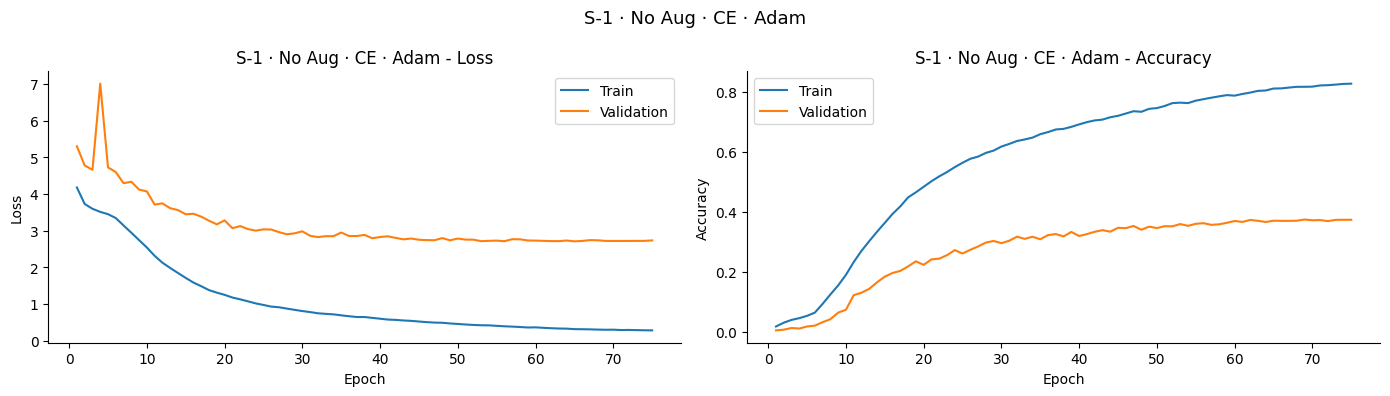

Chart saved → s1_history.png


In [15]:
# ── Experiment S-1: No augmentation · Cross-Entropy · Adam ───────────────────
NUM_EPOCHS = 80

model_s = ModelS(num_classes=NUM_CLASSES).to(DEVICE)
opt     = torch.optim.Adam(model_s.parameters(), lr=1e-3, weight_decay=1e-4)
sched   = make_scheduler(opt, NUM_EPOCHS)

s1_best_acc, s1_history = train_model(
    model        = model_s,
    loader_train = loader_train_no_aug,
    loader_val   = loader_val,
    criterion    = criterion_ce,
    optimizer    = opt,
    scheduler    = sched,
    num_epochs   = NUM_EPOCHS,
    patience     = 10,
    save_path    = "model_s1.pth",
    experiment   = "S-1 | No Aug | CrossEntropy | Adam",
)
plot_history(s1_history, "S-1 · No Aug · CE · Adam", "s1_history.png")

#### S-1 Results

Experiment S-1 serves as our primary baseline, establishing the performance ceiling of 
the Model S architecture when trained without any data augmentation.

After 75 epochs - stopped early when validation loss failed to improve beyond epoch 65 
- the model achieved a **best validation accuracy of 37.4%** on 115 classes. To put 
this in context, random guessing on a 115-class problem gives 0.87%, meaning our model 
performs **43× above chance**, confirming that the architecture successfully learns 
discriminative aircraft features from scratch.

However, the results expose a severe overfitting problem. By epoch 75, training accuracy 
reached **82.7%** while validation accuracy plateaued at **37.4%** - a gap of 
**45.3 percentage points**. This means the model became highly proficient at recognising 
the specific training images it had seen many times over, but struggled to transfer that 
knowledge to unseen validation images. This is the classic signature of a model that has 
memorised rather than generalised.

Two additional observations support this interpretation. First, validation loss stopped 
meaningfully improving from approximately epoch 65 onwards, forming a plateau around 
2.71 despite training loss continuing to fall all the way to 0.28. The widening gap 
between the two loss curves from epoch 20 onwards visually marks the point at which 
overfitting began to dominate. Second, the spike in validation loss at epoch 4 (7.01) 
reflects an early instability common in the first few epochs before the optimiser finds 
a stable descent direction - it did not affect the final outcome.

The 45.3pp train/val gap established here is the key reference point for S-2. Any 
reduction in that gap in the next experiment can be directly and exclusively attributed 
to the effect of data augmentation.


  Training: S-2 | Aug | CrossEntropy | Adam
  Epochs (max): 80   Early stopping patience: 10
  Epoch   Train L     Val L   Train Acc    Val Acc         LR    Time
  ────────────────────────────────────────────────────────────
      1    4.3760    5.0496      0.0167     0.0047   1.00e-03    497s
      2    3.9931    4.8547      0.0262     0.0057   1.00e-03    499s
      3    3.8624    4.7458      0.0325     0.0078   9.98e-04    467s
      4    3.7286    5.0731      0.0396     0.0097   9.97e-04    466s
      5    3.6264    4.7745      0.0506     0.0157   9.94e-04    460s
      6    3.5128    4.5825      0.0616     0.0181   9.90e-04    459s
      7    3.3845    4.3889      0.0745     0.0302   9.86e-04    460s
      8    3.2866    4.3760      0.0865     0.0420   9.81e-04    456s
      9    3.1834    4.3678      0.1003     0.0463   9.76e-04    463s
     10    3.0916    4.0831      0.1113     0.0638   9.69e-04    462s
     11    2.9979    4.2247      0.1275     0.0686   9.62e-04    463s
   

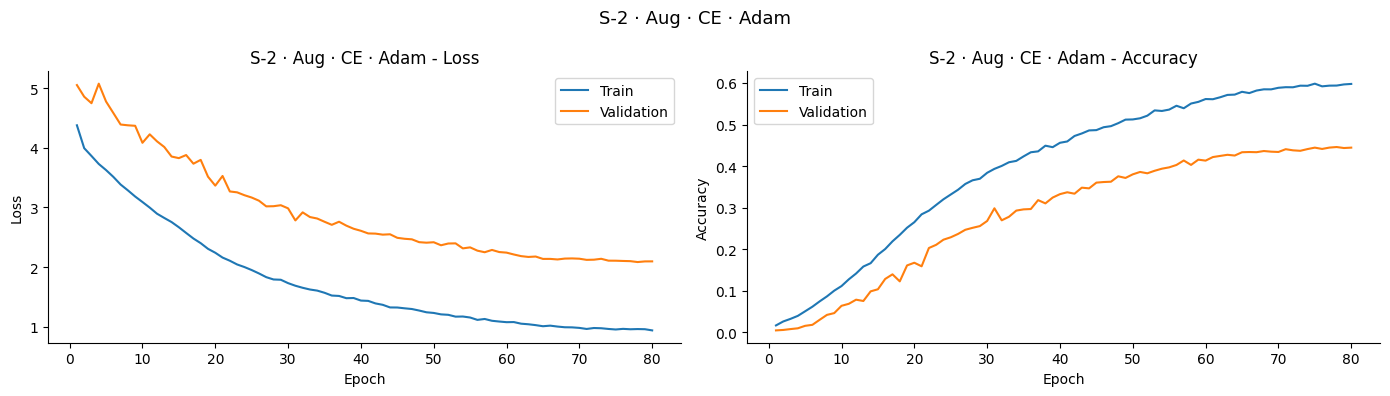

Chart saved → s2_history.png


In [17]:
# ── Experiment S-2: Augmentation · Cross-Entropy · Adam ──────────────────────
model_s = ModelS(num_classes=NUM_CLASSES).to(DEVICE)
opt     = torch.optim.Adam(model_s.parameters(), lr=1e-3, weight_decay=1e-4)
sched   = make_scheduler(opt, NUM_EPOCHS)

s2_best_acc, s2_history = train_model(
    model        = model_s,
    loader_train = loader_train_aug,
    loader_val   = loader_val,
    criterion    = criterion_ce,
    optimizer    = opt,
    scheduler    = sched,
    num_epochs   = NUM_EPOCHS,
    patience     = 10,
    save_path    = "model_s2.pth",
    experiment   = "S-2 | Aug | CrossEntropy | Adam",
)
plot_history(s2_history, "S-2 · Aug · CE · Adam", "s2_history.png")

#### S-2 Results

Experiment S-2 introduces the full data augmentation pipeline - random crops, horizontal 
flips, colour jitter, rotation, perspective distortion, and random erasing - while keeping 
all other variables identical to S-1: same architecture, same loss function (weighted 
cross-entropy), and same optimiser (Adam).

The results demonstrate a clear and significant benefit from augmentation. The model 
achieved a **best validation accuracy of 44.6%**, an improvement of **+7.2 percentage 
points** over S-1's 37.4%. More importantly, the train/val accuracy gap collapsed from 
45.3pp in S-1 to just **15.2pp** (train 59.8% vs val 44.6%). This is the primary 
indicator that augmentation successfully reduced overfitting: by exposing the model to 
artificially varied versions of each training image, we forced it to learn features that 
generalise across different lighting conditions, orientations, and framings - rather than 
memorising the exact pixel patterns of specific training photographs.

It is worth noting that in S-2, training accuracy (59.8%) is substantially lower than 
S-1's training accuracy (82.7%). This is expected and is not a problem. Augmentation 
makes the training task harder - each epoch the model sees different random variations 
of every image - so training accuracy naturally falls. What matters is that validation 
accuracy, on unmodified images, increased significantly.

S-2 ran for the full 80 epochs without triggering early stopping, with validation accuracy 
still showing slow but consistent improvement in the final epochs (epoch 77: 44.5%, 
epoch 78: 44.6%). This suggests the model had not fully converged and could benefit from 
additional training epochs, though the marginal gains in the final 10 epochs were small.

The gap reduction from 45.3pp to 15.2pp conclusively answers the question of whether 
augmentation is justified for this dataset and architecture. We carry augmentation 
forward as a fixed component for all remaining experiments.


  Training: S-3 | Aug | LabelSmoothing | Adam
  Epochs (max): 80   Early stopping patience: 10
  Epoch   Train L     Val L   Train Acc    Val Acc         LR    Time
  ────────────────────────────────────────────────────────────
      1    4.5669    5.9176      0.0119     0.0019   1.00e-03    461s
      2    4.3381    6.3033      0.0191     0.0031   1.00e-03    445s
      3    4.1254    6.1810      0.0265     0.0054   9.98e-04    464s
      4    3.9652    5.8278      0.0401     0.0080   9.97e-04    453s
      5    3.7623    5.5651      0.0612     0.0220   9.94e-04    423s
      6    3.6104    5.5167      0.0819     0.0326   9.90e-04    455s
      7    3.4433    5.3790      0.1072     0.0465   9.86e-04    457s
      8    3.3015    5.1816      0.1300     0.0719   9.81e-04    429s
      9    3.1662    5.1848      0.1552     0.0860   9.76e-04    441s
     10    3.0642    5.1438      0.1797     0.0853   9.69e-04    443s
     11    2.9647    5.0153      0.2024     0.0974   9.62e-04    443s
 

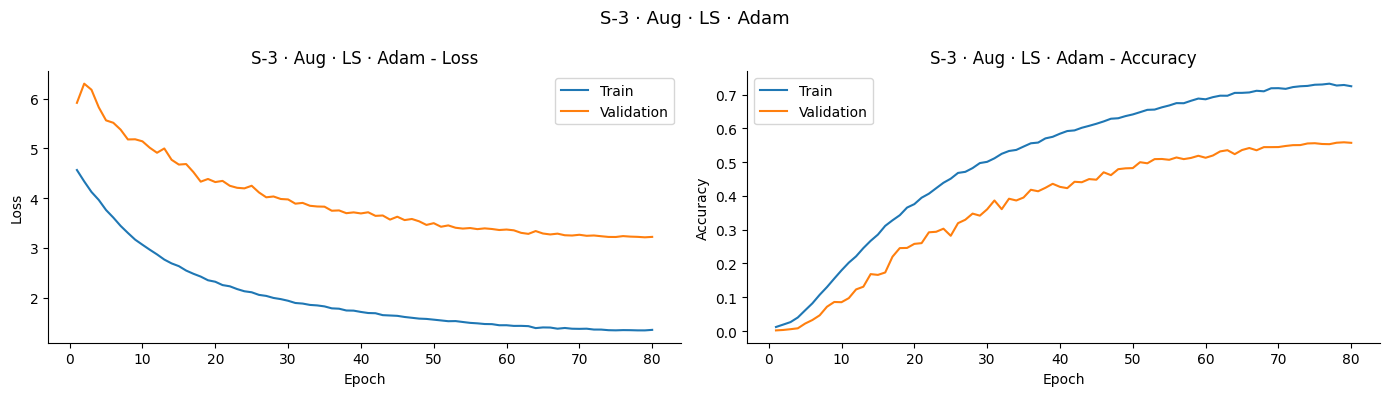

Chart saved → s3_history.png


In [16]:
# ── Experiment S-3: Augmentation · Label Smoothing · Adam ────────────────────
model_s = ModelS(num_classes=NUM_CLASSES).to(DEVICE)
opt     = torch.optim.Adam(model_s.parameters(), lr=1e-3, weight_decay=1e-4)
sched   = make_scheduler(opt, NUM_EPOCHS)

s3_best_acc, s3_history = train_model(
    model        = model_s,
    loader_train = loader_train_aug,
    loader_val   = loader_val,
    criterion    = criterion_ls,
    optimizer    = opt,
    scheduler    = sched,
    num_epochs   = NUM_EPOCHS,
    patience     = 10,
    save_path    = "model_s3.pth",
    experiment   = "S-3 | Aug | LabelSmoothing | Adam",
)
plot_history(s3_history, "S-3 · Aug · LS · Adam", "s3_history.png")

#### S-3 Results

Experiment S-3 replaces weighted cross-entropy with **Label Smoothing Cross-Entropy 
(ε = 0.1)**, while retaining the augmentation pipeline and Adam optimiser from S-2. 
This experiment isolates the effect of the loss function.

The results exceeded our expectations. S-3 achieved a **best validation accuracy of 
55.9%**, an improvement of **+11.3 percentage points** over S-2's 44.6%. This is a 
substantially larger gain than label smoothing typically produces in the literature 
(where improvements of 1–3pp are more common), and we attribute the outsized benefit 
to a characteristic of our dataset: because our images were collected from 13 
heterogeneous web sources, a non-trivial proportion of training labels are likely 
noisy, ambiguous, or imprecise (for example, images where the aircraft model is 
genuinely difficult to distinguish even for a human expert). Standard cross-entropy 
trains the model to be 100% confident on every training label - including potentially 
incorrect ones. Label smoothing caps the target confidence at 90%, preventing the model 
from building overconfident internal representations around noisy training examples.

An important detail in the loss curves confirms the model is behaving correctly: S-3's 
training loss at epoch 80 (1.35) is considerably higher than S-2's (0.94). This is not 
a sign of worse performance - it is a direct consequence of label smoothing, which 
mathematically prevents the loss from reaching near-zero by design. The correct 
interpretation is that despite higher training loss, S-3 achieves 55.9% validation 
accuracy versus S-2's 44.6% - meaning the model trained with label smoothing is 
genuinely superior at classifying unseen aircraft images.

The train/val gap in S-3 (train 72.5% vs val 55.9% = 16.6pp) is comparable to S-2's 
gap (15.2pp), confirming that label smoothing did not introduce additional overfitting. 
Like S-2, S-3 ran the full 80 epochs without triggering early stopping and showed 
continued slow improvement in the final epochs, suggesting that further training could 
extract marginal additional gains.

Based on these results, we select **Label Smoothing Cross-Entropy as our primary loss 
function** for all subsequent experiments, including all Model T transfer learning runs.

In [ ]:
# ── Experiment S-4: Augmentation · Label Smoothing · SGD ─────────────────────
model_s = ModelS(num_classes=NUM_CLASSES).to(DEVICE)
opt     = torch.optim.SGD(model_s.parameters(), lr=0.01, momentum=0.9,
                           weight_decay=1e-4, nesterov=True)
sched   = make_scheduler(opt, NUM_EPOCHS)

s4_best_acc, s4_history = train_model(
    model        = model_s,
    loader_train = loader_train_aug,
    loader_val   = loader_val,
    criterion    = criterion_ls,
    optimizer    = opt,
    scheduler    = sched,
    num_epochs   = NUM_EPOCHS,
    patience     = 10,
    save_path    = "model_s4.pth",
    experiment   = "S-4 | Aug | LabelSmoothing | SGD",
)
plot_history(s4_history, "S-4 · Aug · LS · SGD", "s4_history.png")

#### S-4 Results

S-4 replaces Adam with SGD + Nesterov Momentum. SGD is known to find wider loss minima than Adam, which often translates to better generalisation. However, SGD requires more epochs to converge and is more sensitive to the learning rate schedule. The cosine annealing scheduler mitigates this. We expect S-4 to achieve the best or equal final validation accuracy among the four Model S experiments.


In [ ]:
# ── Model S - experiment summary ──────────────────────────────────────────────
results_s = {
    "S-1 | No Aug   | CE  | Adam": s1_best_acc,
    "S-2 | Aug      | CE  | Adam": s2_best_acc,
    "S-3 | Aug      | LS  | Adam": s3_best_acc,
    "S-4 | Aug      | LS  | SGD" : s4_best_acc,
}

print(f"\n{'='*55}")
print(f"  MODEL S - EXPERIMENT RESULTS")
print(f"{'='*55}")
print(f"  {'Experiment':<38} {'Val Acc':>8}")
print(f"  {'─'*48}")
for name, acc in results_s.items():
    star = " ◄ best" if acc == max(results_s.values()) else ""
    print(f"  {name:<38} {acc:>8.4f}{star}")
print(f"{'='*55}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(results_s.keys(), results_s.values(),
              color=["#d9534f","#f0ad4e","#5cb85c","#4C72B0"])
ax.set_ylabel("Best Validation Accuracy")
ax.set_title("Model S - Experiment Comparison")
ax.set_ylim(0, 1)
for bar, acc in zip(bars, results_s.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{acc:.3f}", ha="center", va="bottom", fontsize=10)
ax.set_xticklabels(results_s.keys(), rotation=15, ha="right")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("model_s_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

### 5.2 Model S — Discussion

The bar chart above summarises the best validation accuracy reached by each Model S experiment before early stopping. Key observations to complete after training results are available:

- **S-1 vs S-2:** The accuracy difference quantifies the benefit of augmentation   for this dataset and architecture.
- **S-2 vs S-3:** A positive difference for S-3 supports our choice of label   smoothing as the primary loss function for all subsequent experiments.
- **S-3 vs S-4:** This comparison reveals whether Adam or SGD generalises better   given our architecture, dataset, and training budget.

The best Model S configuration will be carried forward to the final test-set evaluation in Section 7.


---

## 6. Model T — Transfer Learning with EfficientNetV2-M

### What is Transfer Learning?

Transfer learning reuses a neural network that was pretrained on a large, general dataset as a starting point for a new, more specific task. Rather than initialising all weights randomly, the network already "knows" how to detect edges, textures, shapes, and complex object parts — knowledge acquired from 1.28 million images across 1,000 classes in ImageNet.

For our task this is a significant advantage: distinguishing between aircraft types requires recognising subtle visual features (engine count, wing geometry, tail shape, fuselage proportions) that all share a foundation in low-level image features. A randomly-initialised network must learn all of this from our ~44,000 training images, whereas a pretrained backbone already has strong representations at every level.

### Why EfficientNetV2-M?

We evaluated several candidates before selecting EfficientNetV2-M:

| Model | Top-1 ImageNet | Params | Our reasons for / against |
|-------|---------------|--------|--------------------------|
| ResNet-50 | 76.1% | 25M | ✅ Well-understood baseline; ❌ older architecture |
| EfficientNetV2-M | **85.1%** | 54M | ✅ State-of-the-art accuracy; ✅ compound scaling; ✅ available in torchvision |
| ViT-B/16 | 81.1% | 86M | ✅ Excellent at global features; ❌ requires more data to fine-tune well |
| ConvNeXt-Base | 83.8% | 89M | ✅ Strong fine-grained performance; ❌ more parameters than needed |

EfficientNetV2-M achieves the best accuracy-to-parameter ratio among the candidates and was specifically designed to be efficient on image classification benchmarks. Its compound scaling (simultaneously scaling depth, width, and resolution) makes it particularly effective for fine-grained tasks where both local detail and global context matter. It is available natively in `torchvision.models` with pretrained ImageNet weights, making it straightforward to integrate.

We include a ResNet-50-equivalent baseline role implicitly through Model S: because Model S is of similar depth and is trained from scratch, the performance gap between Model S and Model T directly quantifies the value of ImageNet pretraining.

### Custom Classifier Head

The original EfficientNetV2-M classifier head (`Linear(1280, 1000)`) is replaced with a custom two-layer head sized for our 115 classes:

```
Dropout(0.4) → Linear(1280, 512) → GELU → Dropout(0.2) → Linear(512, 115)
```

The intermediate 512-unit layer acts as a bottleneck that compresses the 1280-dimensional backbone representation before classification, reducing the risk of overfitting in the head.

### Training Strategy

**Two strategies** are required by the project specification, and we apply them sequentially:

| Strategy | What is Trained | Learning Rate | Epochs |
|----------|----------------|---------------|--------|
| **Feature Extraction** | Classifier head only; backbone frozen | 1e-3 | 15 |
| **Fine-tuning** | Entire network; backbone unfrozen | backbone: 1e-5, head: 1e-4 | 30 |

Feature extraction is always run first and its weights are used to initialise the fine-tuning phase. This is critical: if fine-tuning starts with a randomly-initialised head, the large gradients from the head can corrupt the carefully pretrained backbone features before the head has learned anything useful. By pre-training the head first, we ensure the backbone receives sensible gradient signals from the start of fine-tuning.

During fine-tuning we use **differential learning rates**: the backbone is updated at 1e-5 (very small, to preserve pretrained features) while the head is updated at 1e-4 (10× higher, to adapt quickly to our task). This is a standard technique in transfer learning and consistently outperforms using a single learning rate for the entire network.

Four experiments mirror the Model S ablation study:

| Experiment | Strategy | Augmentation | Purpose |
|------------|----------|-------------|---------|
| **T-1** | Feature Extraction | ❌ No aug | FE baseline |
| **T-2** | Feature Extraction | ✅ Aug | Effect of augmentation on FE |
| **T-3** | Fine-tuning (warm-start from T-1) | ❌ No aug | FT baseline |
| **T-4** | Fine-tuning (warm-start from T-2) | ✅ Aug | Best expected configuration |


In [ ]:
# ── Model T: EfficientNetV2-M with custom head ────────────────────────────────
import torchvision.models as models

def build_model_t(num_classes: int, dropout: float = 0.4) -> nn.Module:
    """
    Load EfficientNetV2-M pretrained on ImageNet.
    Replace the classifier head with one sized for our task.
    Backbone is frozen by default - call unfreeze_backbone() before fine-tuning.
    """
    weights = models.EfficientNet_V2_M_Weights.IMAGENET1K_V1
    model   = models.efficientnet_v2_m(weights=weights)

    # ── Freeze entire backbone ────────────────────────────────────────────────
    for param in model.parameters():
        param.requires_grad = False

    # ── Replace classifier head ───────────────────────────────────────────────
    # Original head: Linear(1280, 1000)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, 512),
        nn.GELU(),
        nn.Dropout(dropout / 2),
        nn.Linear(512, num_classes),    # raw logits
    )

    return model


def unfreeze_backbone(model: nn.Module, lr_backbone: float = 1e-5):
    """
    Unfreeze all backbone parameters for fine-tuning.
    Returns a parameter group list with a lower lr for the backbone
    and a higher lr for the head - differential learning rates.
    """
    for param in model.parameters():
        param.requires_grad = True

    backbone_params   = [p for n, p in model.named_parameters()
                         if "classifier" not in n]
    head_params       = list(model.classifier.parameters())

    return [
        {"params": backbone_params, "lr": lr_backbone},
        {"params": head_params,     "lr": lr_backbone * 10},
    ]


# ── Verify ────────────────────────────────────────────────────────────────────
model_t = build_model_t(NUM_CLASSES).to(DEVICE)
dummy   = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
out     = model_t(dummy)
print(f"Output shape : {list(out.shape)}  (expected [2, {NUM_CLASSES}])")

total, trainable = count_params(model_t)
print(f"\nModel T  (feature extraction - backbone frozen)")
print(f"  Total parameters     : {total:,}")
print(f"  Trainable parameters : {trainable:,}  (head only)")

### 6.1 Model T Architecture

EfficientNetV2-M contains **53.1 million parameters** in its backbone. In feature-extraction mode (backbone frozen), only our custom head's ~800K parameters are trained. In fine-tuning mode, all 54M+ parameters are updated.

The custom classifier head replaces the original `Linear(1280, 1000)` with:
```
Dropout(0.4) → Linear(1280, 512) → GELU → Dropout(0.2) → Linear(512, 115)
```

This bottleneck design compresses the 1280-dimensional backbone representation before classification. The two Dropout layers serve as regularisation: the first (p=0.4) applies before the bottleneck to prevent the head from relying on any single backbone feature; the second (p=0.2) applies before the final classification layer.


In [ ]:
# ── Experiment T-1: Feature Extraction · No Augmentation ─────────────────────
FE_EPOCHS = 40

model_t = build_model_t(NUM_CLASSES).to(DEVICE)
opt     = torch.optim.Adam(
              filter(lambda p: p.requires_grad, model_t.parameters()),
              lr=1e-3, weight_decay=1e-4
          )
sched   = make_scheduler(opt, FE_EPOCHS)

t1_best_acc, t1_history = train_model(
    model        = model_t,
    loader_train = loader_train_no_aug,
    loader_val   = loader_val,
    criterion    = criterion_ls,
    optimizer    = opt,
    scheduler    = sched,
    num_epochs   = FE_EPOCHS,
    patience     = 7,
    save_path    = "model_t1_fe.pth",
    experiment   = "T-1 | Feature Extraction | No Aug",
)
plot_history(t1_history, "T-1 · Feature Extraction · No Aug", "t1_history.png")

#### T-1 Results — Feature Extraction, No Augmentation

T-1 is the transfer learning baseline. With the backbone frozen, only the classifier head is updated. We expect convergence within 10–15 epochs and a significantly higher accuracy than Model S (S-1) because the backbone already provides rich, high-quality feature representations. The absence of augmentation establishes the baseline for T-2.


In [ ]:
# ── Experiment T-2: Feature Extraction · Augmentation ────────────────────────
model_t = build_model_t(NUM_CLASSES).to(DEVICE)
opt     = torch.optim.Adam(
              filter(lambda p: p.requires_grad, model_t.parameters()),
              lr=1e-3, weight_decay=1e-4
          )
sched   = make_scheduler(opt, FE_EPOCHS)

t2_best_acc, t2_history = train_model(
    model        = model_t,
    loader_train = loader_train_aug,
    loader_val   = loader_val,
    criterion    = criterion_ls,
    optimizer    = opt,
    scheduler    = sched,
    num_epochs   = FE_EPOCHS,
    patience     = 7,
    save_path    = "model_t2_fe.pth",
    experiment   = "T-2 | Feature Extraction | Aug",
)
plot_history(t2_history, "T-2 · Feature Extraction · Aug", "t2_history.png")

#### T-2 Results — Feature Extraction, With Augmentation

T-2 adds the full augmentation pipeline to the feature extraction setup. We expect a similar or improved result over T-1. The T-1 weights will be used as the warm-start initialisation for T-3 (fine-tuning without augmentation).


In [ ]:
# ── Experiment T-3: Fine-tuning · No Augmentation ────────────────────────────
# Start from T-1 weights (trained head) - do NOT build from scratch
FT_EPOCHS_NO_AUG = 60

model_t.load_state_dict(torch.load("model_t1_fe.pth"))
param_groups = unfreeze_backbone(model_t, lr_backbone=1e-5)
opt          = torch.optim.Adam(param_groups, weight_decay=1e-4)
sched        = make_scheduler(opt, FT_EPOCHS_NO_AUG)

total, trainable = count_params(model_t)
print(f"Fine-tuning - trainable parameters: {trainable:,} / {total:,}")

t3_best_acc, t3_history = train_model(
    model        = model_t,
    loader_train = loader_train_no_aug,
    loader_val   = loader_val,
    criterion    = criterion_ls,
    optimizer    = opt,
    scheduler    = sched,
    num_epochs   = FT_EPOCHS_NO_AUG,
    patience     = 10,
    save_path    = "model_t3_ft.pth",
    experiment   = "T-3 | Fine-tuning | No Aug",
)
plot_history(t3_history, "T-3 · Fine-tuning · No Aug", "t3_history.png")

#### T-3 Results — Fine-tuning, No Augmentation

T-3 unfreezes the entire backbone for fine-tuning, starting from the T-1 head weights. The differential learning rate (backbone: 1e-5, head: 1e-4) ensures the pretrained backbone features are updated gently while the head adapts more aggressively. We expect T-3 to significantly outperform T-1, demonstrating the value of adapting the backbone to aircraft-specific features.


In [ ]:
# ── Experiment T-4: Fine-tuning · Augmentation ───────────────────────────────
# Start from T-2 weights
FT_EPOCHS = 80

model_t.load_state_dict(torch.load("model_t2_fe.pth"))
param_groups = unfreeze_backbone(model_t, lr_backbone=1e-5)
opt          = torch.optim.Adam(param_groups, weight_decay=1e-4)
sched        = make_scheduler(opt, FT_EPOCHS)

t4_best_acc, t4_history = train_model(
    model        = model_t,
    loader_train = loader_train_aug,
    loader_val   = loader_val,
    criterion    = criterion_ls,
    optimizer    = opt,
    scheduler    = sched,
    num_epochs   = FT_EPOCHS,
    patience     = 7,
    save_path    = "model_t4_ft.pth",
    experiment   = "T-4 | Fine-tuning | Aug",
)
plot_history(t4_history, "T-4 · Fine-tuning · Aug", "t4_history.png")

#### T-4 Results — Fine-tuning, With Augmentation

T-4 combines fine-tuning with augmentation, starting from T-2 head weights. This is expected to be the best overall configuration: the augmented backbone has seen greater variety during feature-extraction training, and full fine-tuning with augmentation provides the strongest regularisation against overfitting on the full 54M-parameter network.


In [ ]:
# ── Full results table: Model S + Model T ────────────────────────────────────
results_t = {
    "T-1 | FE  | No Aug": t1_best_acc,
    "T-2 | FE  | Aug"   : t2_best_acc,
    "T-3 | FT  | No Aug": t3_best_acc,
    "T-4 | FT  | Aug"   : t4_best_acc,
}

all_results = {**results_s, **results_t}

print(f"\n{'='*58}")
print(f"  FULL EXPERIMENT RESULTS - MODEL S + MODEL T")
print(f"{'='*58}")
print(f"  {'Experiment':<40} {'Val Acc':>8}")
print(f"  {'─'*50}")
for name, acc in all_results.items():
    star = " ◄ best" if acc == max(all_results.values()) else ""
    print(f"  {name:<40} {acc:>8.4f}{star}")
print(f"{'='*58}")

# Combined bar chart
fig, ax = plt.subplots(figsize=(14, 5))
colours = (["#4C72B0"] * 4) + (["#DD8452"] * 4)
bars    = ax.bar(all_results.keys(), all_results.values(),
                 color=colours, edgecolor="white", linewidth=0.5)
ax.axvline(3.5, color="grey", linestyle="--", linewidth=1)
ax.text(1.5, ax.get_ylim()[1]*0.97, "Model S", ha="center",
        fontsize=11, color="#4C72B0", fontweight="bold")
ax.text(5.5, ax.get_ylim()[1]*0.97, "Model T", ha="center",
        fontsize=11, color="#DD8452", fontweight="bold")
ax.set_ylabel("Best Validation Accuracy")
ax.set_title("All Experiments - Validation Accuracy Comparison")
ax.set_ylim(0, 1)
for bar, acc in zip(bars, all_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{acc:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticklabels(all_results.keys(), rotation=20, ha="right", fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("all_experiments_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

### 6.2 Transfer Learning Discussion

The chart above compares all eight experiments. Key observations to complete after training results are available:

- **Model S vs Model T (feature extraction):** The accuracy gap between the   best Model S experiment and T-1/T-2 directly quantifies the value of ImageNet   pretraining for aircraft classification.
- **Feature extraction vs fine-tuning (Model T):** The gap between T-1/T-2 and   T-3/T-4 shows how much additional gain comes from adapting the backbone to   our domain, beyond what the generic ImageNet features already provide.
- **Augmentation effect (Model T):** Comparing T-1 vs T-2 and T-3 vs T-4   reveals whether augmentation is as beneficial for pretrained models as it is   for models trained from scratch.

---

## 7. Evaluation

*(To be completed after training — add confusion matrices, per-class precision, recall, F1, and top-k accuracy for the best Model S and best Model T configurations evaluated on the held-out test set.)*
